In [18]:
!pip install shapefile
!pip install osgeo
!pip install scikit_posthocs

ERROR: Could not find a version that satisfies the requirement shapefile (from versions: none)
ERROR: No matching distribution found for shapefile
  Using cached osgeo-0.0.1.tar.gz (1.2 kB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [47 lines of output]
      running bdist_wheel
      running build
      /opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
      !!
      
              ********************************************************************************
              Please avoid running ``setup.py`` directly.
              Instead, use pypa/build, pypa/installer or other
              standards-based tools.
      
              See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
              *************

In [19]:
# os tools
import os.path

import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date                 # for saving figures with today's date
import datetime


# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
import cmocean                                           # to add colorbars
from   cmocean               import cm as cmo


# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list


# for MaxEnt plots
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
# import scikit_posthocs       as     sp                   # for stats


# for boxenplots
import seaborn               as     sns
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats

# import pytorch


In [20]:
import mod_plotting as modplot

import importlib
from importlib import reload
reload(modplot)

from mod_plotting import setup_SO_axes

In [21]:
all_socat = pd.read_csv('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/MATLAB-SOCAT/socatv2024_SouthernOceans_DATA.csv')

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gn/T/ipykernel_94286/3515677898.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  all_socat = pd.read_csv('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/MATLAB-SOCAT/socatv2024_SouthernOceans_DATA.csv')


In [22]:
INFO = pd.read_csv('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/MATLAB-SOCAT/socatv2024_SouthernOceans_INFO.csv')

def get_info(expokey):
    return INFO[INFO['Expocode_info'] == expokey]

# QC flag info 

In [23]:
INFO 
# Only using WOCE flags of 2 (good data) for fco2rec (rec="re-calculated")

,Data_Source_DOI_info,Dataset_Name_info,Expocode_info,Platform_Name_info,QC_Flag_info,Start_Time_info,End_Time_info,version_info
0,10.25921/3f59-1405,NaN,069920201125,Sea Explorer,C,2020-11-25,2020-12-10,2021.0N
1,10.25921/3f59-1405,NaN,069920201211,Sea Explorer,C,2020-12-11,2020-12-25,2021.0N
2,10.25921/3f59-1405,NaN,069920201226,Sea Explorer,C,2020-12-26,2021-01-05,2021.0N
3,10.25921/mwwt-4m62,NaN,069920210106,Sea Explorer,C,2021-01-06,2021-01-28,2022.0N
4,10.25921/2dya-8w91,NaN,069920230226,Sea Explorer,C,2023-02-26,2023-04-02,2024.0N
...,...,...,...,...,...,...,...,...
1331,NaN,QUIMA20060921,QUIMA20060921,Quima,D,2006-09-19,2006-09-24,1.3N
1332,NaN,QUIMA20061013,QUIMA20061013,Quima,D,2006-10-13,2006-10-18,1.3N
1333,NaN,QUIMA20061124,QUIMA20061124,Quima,D,2006-11-22,2006-11-27,1.3N
1334,NaN,NaN,"Note for data set(s): 06AQ19911114, 06AQ199112...",NaN,NaN,NaN,NaN,NaN


## 1.0 Resample SOCAT data to match temporal resolution of Argo data

In [24]:
# First restrict SOCAT data to 2014 and later
socat_df = all_socat[all_socat.yr>=2014]
def add_datetime(df):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['yr'].astype(str)) + \
                 pd.to_timedelta(df['day'] - 1, unit='D') + \
                 pd.to_timedelta(df['hh'], unit='h') + \
                 pd.to_timedelta(df['mm'], unit='m') + \
                 pd.to_timedelta(df['ss'], unit='s')
    # df = df.set_index('datetime')
    return df

# Make a dictionary of dataframes, one for each cruise
expokeys = socat_df.expocode.unique() # list of expo codes for each cruise
expo_dict = {key: add_datetime(group) for key, group in socat_df.groupby('expocode')}
expo_dict_3h = {key:None for key in expokeys}


In [25]:
# expokeys = socat_df.expocode.unique()

In [26]:
# expo_dict_3h = {key:None for key in expokeys}

In [27]:
# Resample data to every 3 hours
for expokey in expokeys[:]: # expokey = expokeys[0]
    
    gap_cutoff_hrs = 6 # cutoff time, in hours, to separate out a subID
    new_freq = '3h' # new resampling rate

    # Represents 1 cruise. Sort by datetime first
    expoDF = expo_dict[expokey].set_index('datetime').sort_index()

    # Find temporal gaps in the data
    expoDF['hr_diff'] = expoDF.index.to_series().diff().dt.total_seconds() / 3600 # in hours
    expoDF['temp_mask'] = np.tile(0, len(expoDF))

    # If time difference b/w two consecutive data points is greater than gap_cutoff_hrs, then make a new subID
    subID_index = expoDF[expoDF['hr_diff'] > gap_cutoff_hrs].index
    expoDF.loc[subID_index, 'temp_mask'] = 1
    expoDF['subID'] = expoDF['temp_mask'].cumsum().ffill() # assign subID

    # Now resample data to every 3h
    expoDF_resampled = pd.DataFrame() # for one cruise 

    for i in expoDF.subID.unique():
        dat = expoDF[expoDF.subID == i]
        dat_resampled = pd.DataFrame()
        
        for var in ['latitude', 'longitude', 'fco2rec','sal', 'sst']:
            dat_resampled[var] = dat[var].resample(new_freq).mean().interpolate(method='linear').values

        dat_resampled['datetime'] = dat[var].resample(new_freq).mean().interpolate(method='linear').index
        dat_resampled['expoID'] = str(expokey) + '_id' + str(i) # assign unique expoID

        if len(dat_resampled) > 2: # get rid of short segments 2 data points or fewer
            expoDF_resampled = pd.concat([expoDF_resampled, dat_resampled])

    expo_dict_3h[expokey] = expoDF_resampled

# Store all resampled data in one dataframe
socat_resampled_3h = pd.concat(expo_dict_3h.values())

print('# obs before resampling:', len(socat_df))
print('# obs after resampling:', len(socat_resampled_3h))

# obs before resampling: 4386076
# obs after resampling: 64803


In [40]:
socat_resampled_3h.to_csv('../data/SOCATv2024_SO_resampled_3h.csv', index=False)

In [44]:
temp = pd.read_csv('../data/SOCATv2024_SO_resampled_3h.csv')
temp

,latitude,longitude,fco2rec,sal,sst,datetime,expoID
0,-40.097812,9.450584,350.756693,35.316542,15.511464,2020-01-01 00:00:00,69920201125_id0
1,-40.123935,10.255760,351.317056,35.382889,15.830122,2020-01-01 03:00:00,69920201125_id0
2,-40.160615,11.251351,355.416811,35.517767,16.875344,2020-01-01 06:00:00,69920201125_id0
3,-40.027306,12.339184,367.793889,35.218667,14.449259,2020-01-01 09:00:00,69920201125_id0
4,-39.815454,13.591988,365.484117,35.141644,14.257544,2020-01-01 12:00:00,69920201125_id0
...,...,...,...,...,...,...,...
64798,-33.498540,168.511617,363.662572,35.468533,17.387572,2023-01-26 06:00:00,PAT520231025_id0
64799,-32.684773,167.899881,369.334756,35.567017,18.124917,2023-01-26 09:00:00,PAT520231025_id0
64800,-31.658134,167.153976,366.117037,35.699050,19.419875,2023-01-26 12:00:00,PAT520231025_id0
64801,-31.056609,166.757876,367.384739,35.740867,19.944306,2023-01-26 15:00:00,PAT520231025_id0


In [28]:
print('# obs before resampling:', len(socat_df))
print('# obs after resampling:', len(socat_resampled_3h))

# obs before resampling: 4386076
# obs after resampling: 64803


In [29]:
socat_df.fco2rec_flag.value_counts()

fco2rec_flag
2    4386076
Name: count, dtype: int64

In [30]:
# See which EXPO codes are associated with the most measurements
nobs = {key:len(values) for key, values in expo_dict_3h.items()}
expo_nobs = pd.DataFrame.from_dict(nobs, orient='index').sort_values(by=0, ascending=False)
expo_nobs = expo_nobs.reset_index().rename(columns={'index':'expokey', 0:'nobs'})
expo_nobs.head(10)

# get_info('09F920191214')
get_info(expo_nobs.iloc[10].expokey)

,Data_Source_DOI_info,Dataset_Name_info,Expocode_info,Platform_Name_info,QC_Flag_info,Start_Time_info,End_Time_info,version_info
285,10.3334/cdiac/otg.tsm_sofs_142w_46s,NaN,316420180823,SOFS_142E_46S,C,2018-08-23,2019-03-23,2022.0N


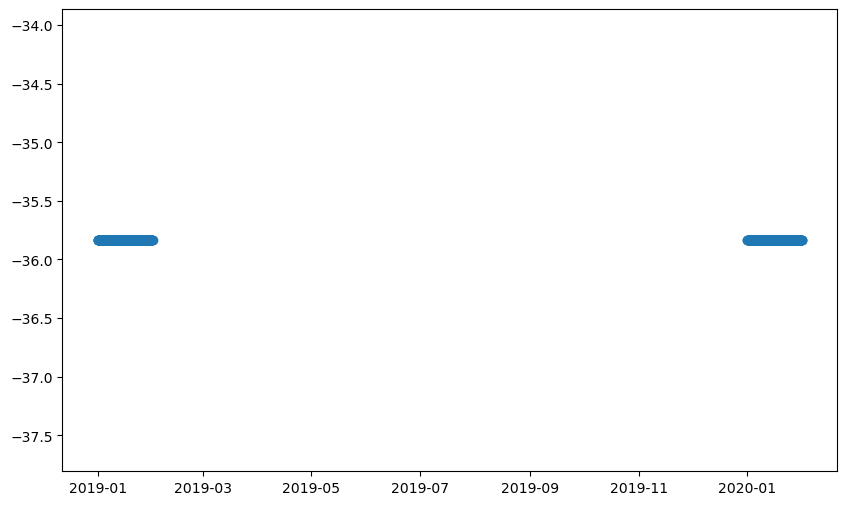

In [31]:
dat = expo_dict_3h['09FS20191118']

fig = plt.figure(figsize=(10, 6))
ax = fig.gca()

ax.scatter(dat.datetime, dat.latitude)
plt.show()

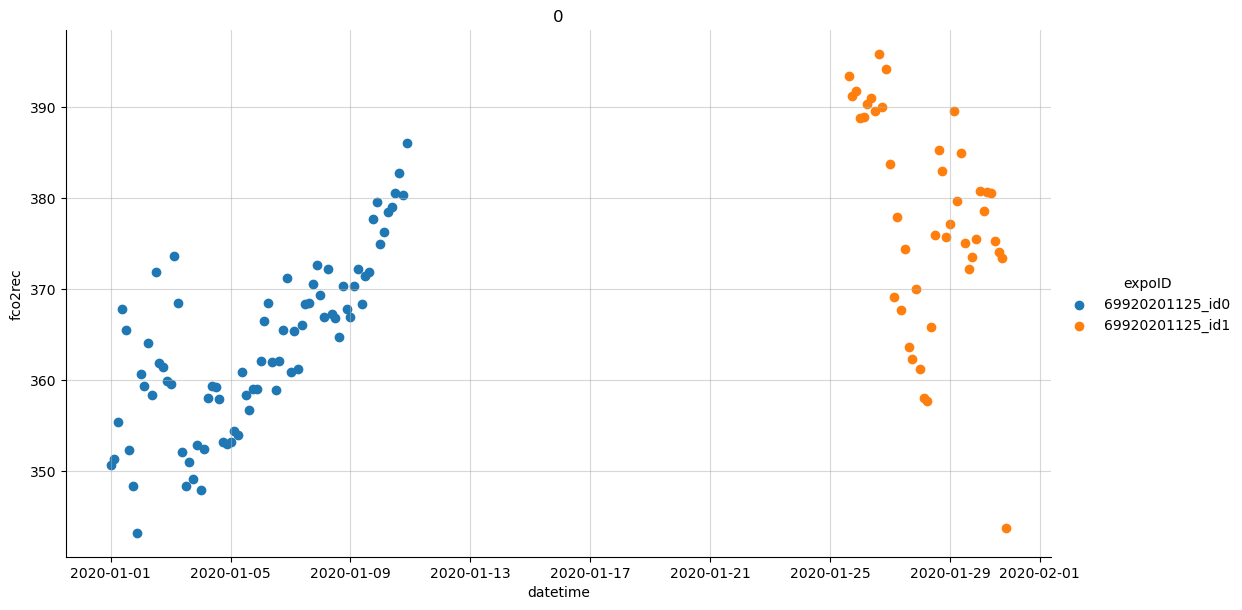

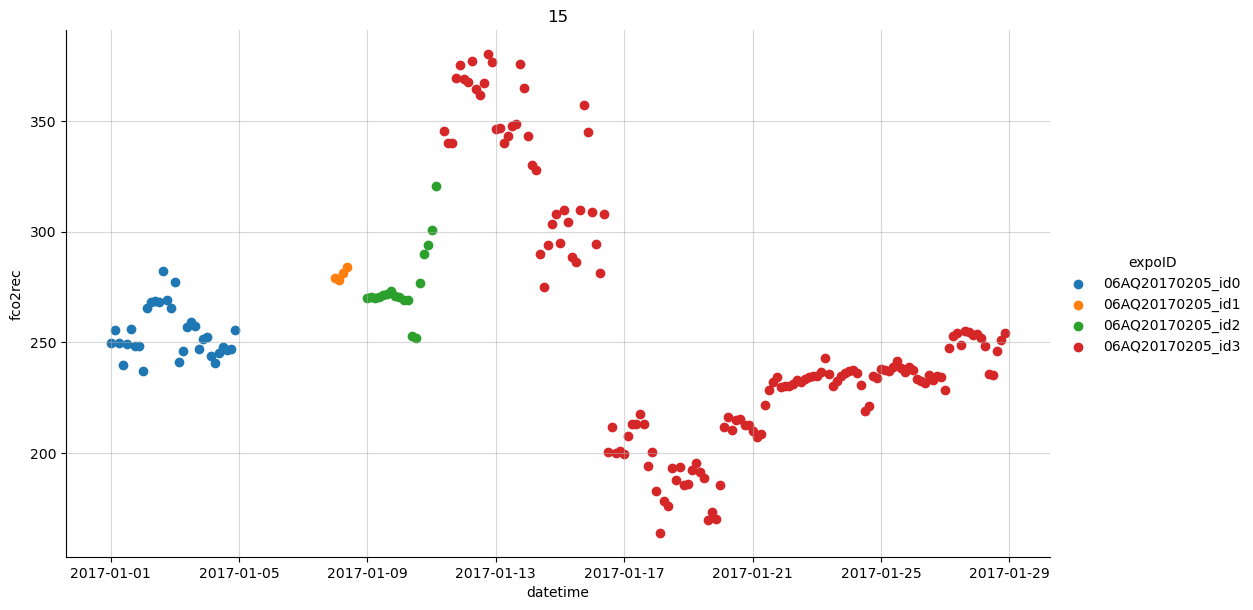

In [32]:
# for i in np.arange(0,20):
#     dat = expo_dict_3h[expo_nobs.iloc[i].expokey]

for i in [0,15]:
    dat = expo_dict_3h[expokeys[i]]
    # dat = dat[dat.datetime.dt.year > 2019]

    # fig = plt.figure(figsize=(10, 5))
    fg = sns.FacetGrid(data=dat, hue='expoID', hue_order=dat.expoID.unique(), aspect=1.8, height=6)
    fg.map(plt.scatter, 'datetime', 'fco2rec').add_legend()

    ax = plt.gca()
    ax.grid(alpha=0.5)
    ax.set_title(str(i))

    plt.show()

# 15 

In [33]:
from importlib import reload
import mod_plotting as modplot

from modplot import map_southern_ocean_axes_setup


ModuleNotFoundError: No module named 'modplot'

In [24]:
# Plotting

# os tools
import os.path

import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date                 # for saving figures with today's date
import datetime


# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
import cmocean                                           # to add colorbars
from   cmocean               import cm as cmo


# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list


# for MaxEnt plots
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
import scikit_posthocs       as     sp                   # for stats


# for boxenplots
import seaborn               as     sns
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats

# Function to plot Southern Ocean map on an axis
##################################################################
######  Set up Southern Ocean Map  ###############################
##################################################################

def map_southern_ocean_axes_setup(
    ax:                    matplotlib.axes.Axes,
    fig:                   matplotlib.figure.Figure,
    max_latitude:          float = -30,
    add_gridlines:         bool  = True,
    color_land:            bool  = False,
    land_edgecolor:        str   = 'grey',
    land_facecolor:        str   = 'grey',
    fontsize:              float = 10,
    map_facecolor:         str   = 'white',
    coast_linewidth:       float = 0.3,
    gridlines_linewidth:   float = 0.5,
    girdlines_color:       str   = 'grey',
    gridlines_alpha:       float = 0.5,
    longitude_label_color: str   = 'grey',
    latitude_label_color:  str   = 'grey'
) -> None:
    """
    This function sets up the subplot so that it is a cartopy map of the Southern Ocean.
    returns void as the ax and figure objects are pointers not data.
    Args:
        ax  (matplotlib.axes.Axes):     The axis object to add the map to.
        fig (matplotlib.figure.Figure): The figure object for the figure in general.
        add_gridlines (bool):           Whether or not to add gridlines to the plot.
    """
    
    
    ### Limit the map to -40 degrees latitude and below.
    ax.set_extent([-180, 180, -90, max_latitude+0.6], ccrs.PlateCarree())  # set to -29.4 for map out to 30 degrees or -39.4 for map out to 40 degrees
   
    ### Tune the subplot layout
    # fig.subplots_adjust(bottom=0.05, top=0.95, left=0.04, right=0.95, wspace=0.02)
    
    ### Make the background of the plot white
    ax.set_facecolor(map_facecolor)

    ### Make SO plot boundary a circle
    def plot_circle_boundary() -> None:
        """
        Make SO plot boundary a circle.
        Compute a circle in axes coordinates, which we can use as a boundary for the map.
        We can pan/zoom as much as we like - the boundary will be permanently circular.
        """
        theta  = np.linspace(0, 2 * np.pi, 100)
        center, radius = [0.5, 0.5], 0.5  ## could use 0.45 here, as Simon Thomas did
        verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform = ax.transAxes)

    plot_circle_boundary()


    ### Add gridlines (if True)
    if add_gridlines:
        ax.gridlines(color = girdlines_color, alpha = gridlines_alpha, linewidth = gridlines_linewidth)
        
                # specifying xlocs/ylocs yields number of meridian/parallel lines
        dmeridian = 60  # spacing for lines of meridian
        dparallel = 20  # spacing for lines of parallel -- can change this to 10
        num_merid = int(360/dmeridian + 1)
        num_parra = int(180/dparallel + 1)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                          xlocs=np.linspace(-180, 180, num_merid), 
                          ylocs=np.linspace(-90, 90, num_parra), 
                          linestyle="-", linewidth=0.5, color='grey', alpha=gridlines_alpha)
        
        # for label alignment
        va = 'center' # also bottom, top
        ha = 'center' # right, left
        degree_symbol = u'\u00B0'

        # for locations of (meridional/longitude) labels
        lond = np.linspace(-180, 180, num_merid)
        latd = np.zeros(len(lond))

        # for (alon, alat) in zip(lond, latd):
        #     projx1, projy1 = ax.projection.transform_point(alon, max_latitude+1, ccrs.Geodetic())  # set to -29 for map out to 30 degrees or -39 for a map out to 40 degrees
        #     if alon>-180 and alon<0:
        #         ha = 'right'
        #         va = 'center'
        #     if alon>0 and alon<180:
        #         ha = 'left'
        #         va = 'center'
        #     if np.abs(alon-0)<0.01:
        #         ha = 'center'
        #         va = 'bottom'
        #     if alon==-180:
        #         ha = 'center'
        #         va = 'top'
        #     if (alon<180):
        #         txt =  ' {0} '.format(str(int(alon)))+degree_symbol
        #         ax.text(projx1, projy1, txt, va=va, ha=ha, color=latitude_label_color, fontsize=fontsize)
                
        # # for locations of (meridional/longitude) labels select longitude: 315 for label positioning
        # lond2 = 60*np.ones(len(lond))
        # latd2 = np.linspace(-90, 90, num_parra)
        # va, ha = 'center', 'center'
        # for (alon, alat) in zip(lond2, latd2):
        #     projx1, projy1 = ax.projection.transform_point(alon, alat, ccrs.Geodetic())
        #     txt =  ' {0} '.format(str(int(alat)))+degree_symbol
        #     ax.text(projx1, projy1, txt, va=va, ha=ha, color=longitude_label_color, fontsize=fontsize) 
        
        
    ### Add in coastlines/features
    if color_land:
        ax.add_feature(cfeature.LAND, zorder=1, linewidth = coast_linewidth, edgecolor=land_edgecolor, facecolor=land_facecolor)
    else:
        ax.coastlines(resolution = "50m", zorder=1, linewidth = coast_linewidth)
### Make SO plot boundary a circle
def plot_circle_boundary(ax) -> None:
    """
    Make SO plot boundary a circle.
    Compute a circle in axes coordinates, which we can use as a boundary for the map.
    We can pan/zoom as much as we like - the boundary will be permanently circular.
    """
    theta  = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5  ## could use 0.45 here, as Simon Thomas did
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
## Sea Ice Extent and Fronts
so_fronts = shapefile.Reader('shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points
## Discrete Colormap
def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""

    # Note that if base_cmap is a string or None, you can simply do
    #    return plt.cm.get_cmap(base_cmap, N)
    # The following works for string, None, or a colormap instance:

    base       = matplotlib.colormaps.get_cmap(base_cmap)
    
    color_list = base(np.linspace(0, 1, N))
    cmap_name  = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)
import mod_plotting as modplot
from modplot import map_southern_ocean_axes_setup

#####################################################################################################################
#################  SET WHERE TO SAVE FIGURE  ########################################################################
#####################################################################################################################

savepath                     = '../results/Paper_Figures/'
savename_profile_histograms  = 'Figure_1_Profile_Histograms'
savename_maxent_maps         = 'Figure_2_MaxEnt_Maps'
savename_gmm_maps            = 'Figure_3_GMM_Maps'
savename_dic_plot            = 'Figure_4_DIC_box_and_violin_plots'
savename_dic_siz             = 'Figure_5_DIC_in_SIZ'
savename_phytobase           = 'Supp_Fig_PhytoBase_data'




#####################################################################################################################
#################  COLOR PALETTES  ##################################################################################
#####################################################################################################################

greens_purples_palette = {'yellowgreen' : '#bce784',
                          'teal'        : '#5dd39e',
                          'blue'        : '#348aa7',
                          'bluepurple'  : '#525174',
                          'eggplant'    : '#513b56'}

reds_yellow_palette = {'almostblack' : '#220901',
                       'darkred'     : '#621708',
                       'red'         : '#941b0c',
                       'orange'      : '#bc3908',
                       'yellow'      : '#f6aa1c'}

blues_palette = {'darkblue'   : '#133c55',
                 'bluegrey'   : '#386fa4',
                 'mediumblue' : '#59a5d8',
                 'skyblue'    : '#84d2f6',
                 'iceblue'    : '#91e5f6'}

grays_palette = {'darkgray'        : '#333333', 
                 'mediumdarkgray'  : '#666666', 
                 'mediumlightgray' : '#999999', 
                 'lightgray3'      : '#aaaaaa',
                 'lightgray2'      : '#bbbbbb',
                 'lightgray'       : '#cccccc'}

rygb_palette = {'pink'   : '#E05A95',
                'yellow' : '#F5C24E',
                'green'  : '#50BA54',
                'blue'   : '#6493F5'}

rainbow5_palette = {'red'    : '#E06247',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'purple' : '#BA58E8'}

rainbow6_palette = {'red'    : '#E06247',
                    'orange' : '#E67951',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'indigo' : '#5B61C2',
                    'purple' : '#BA58E8',
                    'pink'   : '#CC58C0'}

sunset_palette = {'lightyellow'  : '#41476b',
                   'yelloworange' : '#675478',
                   'orange'       : '#9e6374',
                   'red'          : '#c67b6f',
                   'merlo'        : '#de9b71',
                   'purple'       : '#efbc82',
                   'indigo'       : '#fbdfa2'}

sunset_palettes = {'darkblue'     : '#1D457F', 
                   'bluepurple'   : '#61599D', 
                   'mediumpurple' : '#805DA1', 
                   'darkpink'     : '#C36377',
                   'orange'       : '#EB7F54',
                   'yellow'       : '#F2AF4A'}

shuksan_palette = {'a' : '#33271e',
                   'b' : '#74677e',
                   'c' : '#ac8eab',
                   'd' : '#d7b1c5',
                   'e' : '#ebbdc8',
                   'f' : '#f2cec7',
                   'g' : '#f8e3d1',
                   'h' : '#fefbe9'}

lake_palette = {'a' : '#362904',
                'b' : '#54450f',
                'c' : '#45681e',
                'd' : '#4a9152',
                'e' : '#64a8a8',
                'f' : '#85b6ce',
                'g' : '#cde5f9',
                'h' : '#eef3ff'}

sailboat_palette = {'red'    : '#6e7cb9',
                    'orange' : '#7bbcd5',
                    'yellow' : '#d0e2af',
                    'green'  : '#f5db99',
                    'blue'   : '#e89c81',
                    'purple' : '#d2848d'}

sailboat_bright_palette = {'purple' : '#A692F0',
                           'blue'   : '#73CCDE',
                           'green'  : '#A3E386',
                           'yellow' : '#F5DB64',
                           'orange' : '#F59953',
                           'red'    : '#F06F85'}

sailboat_bright_palette_7 = {'pink'   : '#EB77EF',
                             'purple' : '#A692F0',
                             'blue'   : '#73CCDE',
                             'green'  : '#A3E386',
                             'yellow' : '#F5DB64',
                             'orange' : '#F59953',
                             'red'    : '#EF6A61'}

sailboat_dark_palette_7 = {'pink'   : '#B55CB8',
                           'purple' : '#8C7BBC',
                           'blue'   : '#5FA9AE',
                           'green'  : '#82B56B',
                           'yellow' : '#C7B152',
                           'orange' : '#D68649',
                           'red'    : '#C95B53'}

thermal7_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a'}


thermal8_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a',
                    'green'      : '#81F058'}

warm_palette_5 = {'blue'   : '#1f7cff',
                  'purple' : '#d160e0',
                  'pink'   : '#ff4c9f',
                  'orange' : '#ff7056',
                  'yellow' : '#ffa600'}

warm_palette_6 = {'bright_blue'   : '#1f7cff',
                  'medium_purple' : '#bc66ea',
                  'fuschia'       : '#ff4fbb',
                  'bright_pink'   : '#ff5482',
                  'orange'        : '#ff7b48',
                  'yellow'        : '#ffa600'}


###### TAXA COLORS ######    
# Internal colors
# taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#D26A6F', 'Prymnesiophyceae':'#CFC342', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: red, phaeo: yellow
taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#2CA39D', 'Prymnesiophyceae':'#B2387F', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: teal, phaeo: merlo
# Border colors
# taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#FF7F86', 'Prymnesiophyceae':'#F2E44E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: red, phaeo: yellow
taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#1E6E6A', 'Prymnesiophyceae':'#85295E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: teal, phaeo: merlo

###### NAN COLORS ######  
# color_for_nan = grays_palette['mediumdarkgray']
color_for_nan = grays_palette['mediumlightgray']

###### DIC COLORS ######  
# dic_palette = {'low_dic':'#784FB4', 'mid_dic':'#757DDD', 'high_dic':'#A0CBE3'}
dic_palette = {'low_dic':'#6B3965', 'mid_dic':'#ae71a6', 'high_dic':'#f5aeed'}



# light grey: #'#d7dce8',


#####################################################################################################################
#################  UNIVERSAL PLOT PARAMETERS FOR PAPER FIGURES  #####################################################
#####################################################################################################################

#### FIGURE SIZE
fig_width       = 6   # inches
fig_height      = 6   # inches
aspect_ratio    = 0.5

figsize_fig1              = [7, 6]         # x, y in inches
figsize_fig2              = [6, 4]         # x, y in inches
figsize_fig3              = [9, 4.5]       # x, y in inches
figsize_fig4              = [5, 5]         # x, y in inches
figsize_fig5              = [7, 6]         # x, y in inches
figsize_suppfig_phytobase = [7, 4]         # x, y in inches

#### FONT SIZES
fontsize_large        = 20
fontsize_medium       = 12             # size of main font in figure
fontsize_small        = 10             # size of detailed font in figure
fontsize_tiny         = 8              # size of detailed font in figure

# fontsize_large  = 8
# fontsize_medium = 6
# fontsize_small  = 4


#### MARKER AND LINE SIZES
paper_markersize                   = 2
paper_markersize_highlighted_group = 1
paper_markersize_not_highlighted   = 0.25

axis_linewidth_map           = 3
axis_linewidth_plot          = 1
linewidth             = 1              # width of line in lineplots
plot_border_linewidth = 1
axis_linewidth        = 2
paper_coast_linewidth = 1
tick_width            = 1.75
tick_length           = 6

front_linewidth       = 0.5

#### PLOT COLORS
plot_facecolor          = '#E9F5F5'  # '#E6F1F1'
overplot_label_color    = '#666666' #  '#EFF3FC'  # '#7B878F'
histogram_bin_edgecolor = '#666666'  # '#EFF3FC'
histogram_bin_color     = shuksan_palette['d']



# darker_label_color      = '#C9CCD4'
# paper_outline_color     =  '#666666'  # grey40 in R
# background_poster_color = '#14417C'
# poster_text_color       = '#B1BED1'



# colors assigned for all plots:

# General for all plots
paper_axes_color     = '#666666'  # grey40 in R
paper_text_color     = 'pink'
paper_plot_facecolor = 'none'

axes_edgecolor = paper_axes_color


# Land for map
paper_land_facecolor = paper_axes_color # '#7B878F'
paper_front_color    = 'pink'


# Fronts and sea ice edge
paper_stf_edgecolor_gray   = grays_palette['mediumlightgray']
paper_saf_edgecolor_gray   = grays_palette['lightgray3']
paper_pf_edgecolor_gray    = grays_palette['lightgray2']
paper_sacc_edgecolor_gray  = grays_palette['lightgray']
paper_sie_facecolor_blue   = blues_palette['iceblue']  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_blue   = blues_palette['iceblue']

paper_stf_edgecolor_white  = '#EFF3FC'
paper_saf_edgecolor_white  = '#EFF3FC'
paper_pf_edgecolor_white   = '#EFF3FC'
paper_sacc_edgecolor_white = '#EFF3FC'
paper_sie_facecolor_white  = '#EFF3FC'  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_white  = '#EFF3FC'


# Histogram map
cmap_histogram_map = cmo.thermal


# GMM class colors
paper_gmm_class_2_siz_color     = sailboat_bright_palette_7['blue']
paper_gmm_class_4_asz_color     = sailboat_bright_palette_7['green']
paper_gmm_class_6_pfz_color     = sailboat_bright_palette_7['pink']
paper_gmm_class_0_sazI_color    = sailboat_bright_palette_7['red']
paper_gmm_class_5_sazP_color    = sailboat_bright_palette_7['orange']
paper_gmm_class_3_stz_color     = sailboat_bright_palette_7['yellow']
paper_gmm_class_1_hum_color     = sailboat_bright_palette_7['purple']

paper_gmm_not_highlighted_color = color_for_nan


paper_gmm_class_2_siz_color_dark     = sailboat_dark_palette_7['blue']
paper_gmm_class_4_asz_color_dark     = sailboat_dark_palette_7['green']
paper_gmm_class_6_pfz_color_dark     = sailboat_dark_palette_7['pink']
paper_gmm_class_0_sazI_color_dark    = sailboat_dark_palette_7['red']
paper_gmm_class_5_sazP_color_dark    = sailboat_dark_palette_7['orange']
paper_gmm_class_3_stz_color_dark     = sailboat_dark_palette_7['yellow']
paper_gmm_class_1_hum_color_dark     = sailboat_dark_palette_7['purple']


# the defs should stay the same to not change code below, but what they are assigned can change

# Map colors and lines
markersize                   = paper_markersize
markersize_highlighted_group = paper_markersize_highlighted_group
markersize_not_highlighted   = paper_markersize_not_highlighted
coast_linewidth              = paper_coast_linewidth
plot_edgecolor               = paper_axes_color
plot_facecolor               = paper_plot_facecolor
land_edgecolor               = paper_land_facecolor
land_facecolor               = paper_land_facecolor


# Fronts and sea ice edge colors
stf_edgecolor_histogram  = paper_stf_edgecolor_white
saf_edgecolor_histogram  = paper_saf_edgecolor_white
pf_edgecolor_histogram   = paper_pf_edgecolor_white
sacc_edgecolor_histogram = paper_sacc_edgecolor_white
sie_edgecolor_histogram  = paper_sie_edgecolor_white

stf_edgecolor_gmm_map    = paper_stf_edgecolor_gray
saf_edgecolor_gmm_map    = paper_saf_edgecolor_gray
pf_edgecolor_gmm_map     = paper_pf_edgecolor_gray
sacc_edgecolor_gmm_map   = paper_sacc_edgecolor_gray
sie_edgecolor_gmm_map    = paper_sie_edgecolor_blue
sie_facecolor_gmm_map    = paper_sie_facecolor_blue

fronts_edgecolor_maxent  = paper_stf_edgecolor_white

# GMM class colors
gmm_class_2_siz_color     = paper_gmm_class_2_siz_color
gmm_class_4_asz_color     = paper_gmm_class_4_asz_color
gmm_class_6_pfz_color     = paper_gmm_class_6_pfz_color
gmm_class_0_sazI_color    = paper_gmm_class_0_sazI_color
gmm_class_5_sazP_color    = paper_gmm_class_5_sazP_color
gmm_class_3_stz_color     = paper_gmm_class_3_stz_color
gmm_class_1_hum_color     = paper_gmm_class_1_hum_color
gmm_not_highlighted_color = paper_gmm_not_highlighted_color

gmm_class_2_siz_color_dark     = paper_gmm_class_2_siz_color_dark
gmm_class_4_asz_color_dark     = paper_gmm_class_4_asz_color_dark
gmm_class_6_pfz_color_dark     = paper_gmm_class_6_pfz_color_dark
gmm_class_0_sazI_color_dark    = paper_gmm_class_0_sazI_color_dark
gmm_class_5_sazP_color_dark    = paper_gmm_class_5_sazP_color_dark
gmm_class_3_stz_color_dark     = paper_gmm_class_3_stz_color_dark
gmm_class_1_hum_color_dark     = paper_gmm_class_1_hum_color_dark
# gmm_not_highlighted_color_dark = paper_gmm_not_highlighted_color_dark



#####  SET FOR ALL PLOTS  ######
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

plt.rc('font',   size      = fontsize_medium)       # controls default text sizes
plt.rc('axes',   titlesize = fontsize_medium)       # fontsize of the axes title
plt.rc('axes',   labelsize = fontsize_medium)       # fontsize of the x and y labels
plt.rc('xtick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('ytick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('legend', fontsize  = fontsize_medium)       # legend fontsize
plt.rc('figure', titlesize = fontsize_large)        # fontsize of the figure title

# plt.rcParams['xtick.labelsize']   = fontsize_small
# plt.rcParams['ytick.labelsize']   = fontsize_small

plt.rcParams['axes.edgecolor']    = paper_axes_color
plt.rcParams['axes.linewidth']    = axis_linewidth
plt.rcParams['axes.labelcolor']   = paper_axes_color
plt.rcParams['axes.facecolor']    = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
# plt.rcParams["axes.edgecolor"] = paper_outline_color
# plt.rcParams["axes.linewidth"] = axis_linewidth_map

plt.rcParams['text.color']        = paper_axes_color
plt.rcParams['xtick.color']       = paper_axes_color
plt.rcParams['ytick.color']       = paper_axes_color
plt.rcParams['xtick.labelcolor']  = paper_axes_color
plt.rcParams['ytick.labelcolor']  = paper_axes_color
plt.rcParams['xtick.major.width'] = tick_width
plt.rcParams['ytick.major.width'] = tick_width
plt.rcParams['xtick.major.size']  = tick_length
plt.rcParams['ytick.major.size']  = tick_length




# ###### SET UP PLOT ######    
# plt.rcParams["axes.edgecolor"]    = axes_edgecolor
# plt.rcParams["axes.facecolor"]    = axes_facecolor
# plt.rcParams["axes.linewidth"]    = axes_linewidth
# plt.rcParams["axes.labelcolor"]   = axes_edgecolor
# plt.rcParams["xtick.bottom"]      = False
# plt.rcParams["xtick.color"]       = axes_edgecolor
# plt.rcParams["ytick.left"]        = True
# plt.rcParams["ytick.color"]       = axes_edgecolor
# plt.rcParams["ytick.major.size"]  = 7
# plt.rcParams["ytick.major.width"] = 2
# plt.rcParams["ytick.labelsize"]   = fontsize_medium
# plt.rcParams["savefig.facecolor"] = axes_facecolor
# plt.rcParams["figure.facecolor"]  = 'none'

###### SET UP PLOT ######
map_proj = ccrs.SouthPolarStereo()


fig  = plt.figure(figsize=[10,10], dpi=300) # inches
ax1  = plt.subplot(projection = map_proj)


###### SET UP MAP ######
# Set up plot axes
map_southern_ocean_axes_setup(ax1, fig, 
                              add_gridlines         = False, 
                              color_land            = True,
                              land_facecolor        = land_facecolor,
                              land_edgecolor        = land_edgecolor,
                              fontsize              = fontsize_large,
                              map_facecolor         = plot_facecolor, #'#d7dce8',
                              coast_linewidth       = coast_linewidth)


### Add front and sea ice edge
stf_patch  = plt.Polygon(stf,  fill=False, edgecolor=stf_edgecolor_gmm_map,   zorder=15)
saf_patch  = plt.Polygon(saf,  fill=False, edgecolor=saf_edgecolor_gmm_map,   zorder=14)
pf_patch   = plt.Polygon(pf,   fill=False, edgecolor=pf_edgecolor_gmm_map,    zorder=13)
sacc_patch = plt.Polygon(sacc, fill=False, edgecolor=sacc_edgecolor_gmm_map,  zorder=12)
sie_patch  = plt.Polygon(sie,  fill=True,  edgecolor=sie_edgecolor_gmm_map,   zorder=0,  facecolor=sie_facecolor_gmm_map, alpha=0.4)

ax1.add_patch(stf_patch)
ax1.add_patch(saf_patch)
ax1.add_patch(pf_patch)
ax1.add_patch(sacc_patch)
ax1.add_patch(sie_patch)


### Add land on top
ax1.add_feature(cfeature.LAND, zorder=16, linewidth = coast_linewidth, edgecolor = land_edgecolor, facecolor = land_facecolor)

### 7 CLASSES
# plt.scatter(x=profiles_class3.longitude+180, y=profiles_class3.latitude, c=sailboat_bright_palette_7['yellow'],  transform=ccrs.PlateCarree(), zorder=-2,   s=markersize)
# plt.scatter(x=profiles_class0.longitude+180, y=profiles_class0.latitude, c=sailboat_bright_palette_7['red'],     transform=ccrs.PlateCarree(), zorder=-1,   s=markersize)
# plt.scatter(x=profiles_class1.longitude+180, y=profiles_class1.latitude, c=sailboat_bright_palette_7['purple'],  transform=ccrs.PlateCarree(), zorder=8,   s=markersize)
# plt.scatter(x=profiles_class2.longitude+180, y=profiles_class2.latitude, c=sailboat_bright_palette_7['blue'],    transform=ccrs.PlateCarree(), zorder=9,   s=markersize)
# plt.scatter(x=profiles_class4.longitude+180, y=profiles_class4.latitude, c=sailboat_bright_palette_7['green'],   transform=ccrs.PlateCarree(), zorder=10,  s=markersize)
# plt.scatter(x=profiles_class5.longitude+180, y=profiles_class5.latitude, c=sailboat_bright_palette_7['orange'],  transform=ccrs.PlateCarree(), zorder=11,  s=markersize)
# plt.scatter(x=profiles_class6.longitude+180, y=profiles_class6.latitude, c=sailboat_bright_palette_7['pink'],    transform=ccrs.PlateCarree(), zorder=0,  s=markersize)


plot_circle_boundary(ax1)  


ShapefileException: Unable to open ../shapefiles/fronts/so_fronts.dbf or ../shapefiles/fronts/so_fronts.shp.

## bandpass


In [111]:
# Make lowpass filter 

from scipy.signal import butter, filtfilt

def bpfilter_fco2(fco2_reg, fs=1/24/4, lowcut=1/12, highcut=2, order=5):
    """ 
    @param: 
    fco2_reg: regularly spaced time series with datetime index"""

    fco2_reg = fco2_reg.dropna()

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist


    b, a = butter(order, [lowcut, highcut], btype='band')

    foc2_filtered = filtfilt(b, a, fco2_reg.values)

    return fco2_filtered


# def butter_bandpass(lowcut, highcut, fs, order=5):
#     nyquist = 0.5 * fs
#     low = lowcut / nyquist
#     high = highcut / nyquist
#     b, a = butter(order, [low, high], btype='band')
#     return b, a

# def bandpass_filter(data, lowcut, highcut, fs, order=5):
#     b, a = butter_bandpass(lowcut, highcut, fs, order)
#     y = filtfilt(b, a, data)
#     return y

In [112]:
bpfilter_fco2(cruise_fco2_reg)

ValueError: Digital filter critical frequencies must be 0 < Wn < 1

In [23]:
df_info = pd.read_csv('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/MATLAB-SOCAT/socatv2024_SouthernOceans_INFO.csv')

In [24]:
df_info

,Data_Source_DOI_info,Dataset_Name_info,Expocode_info,Platform_Name_info,QC_Flag_info,Start_Time_info,End_Time_info,version_info
0,10.25921/3f59-1405,NaN,069920201125,Sea Explorer,C,2020-11-25,2020-12-10,2021.0N
1,10.25921/3f59-1405,NaN,069920201211,Sea Explorer,C,2020-12-11,2020-12-25,2021.0N
2,10.25921/3f59-1405,NaN,069920201226,Sea Explorer,C,2020-12-26,2021-01-05,2021.0N
3,10.25921/mwwt-4m62,NaN,069920210106,Sea Explorer,C,2021-01-06,2021-01-28,2022.0N
4,10.25921/2dya-8w91,NaN,069920230226,Sea Explorer,C,2023-02-26,2023-04-02,2024.0N
...,...,...,...,...,...,...,...,...
1331,NaN,QUIMA20060921,QUIMA20060921,Quima,D,2006-09-19,2006-09-24,1.3N
1332,NaN,QUIMA20061013,QUIMA20061013,Quima,D,2006-10-13,2006-10-18,1.3N
1333,NaN,QUIMA20061124,QUIMA20061124,Quima,D,2006-11-22,2006-11-27,1.3N
1334,NaN,NaN,"Note for data set(s): 06AQ19911114, 06AQ199112...",NaN,NaN,NaN,NaN,NaN


In [8]:
#####################################################################################################################
#################  SET WHERE TO SAVE FIGURE  ########################################################################
#####################################################################################################################

# savepath                     = '../results/Paper_Figures/'
# savename_profile_histograms  = 'Figure_1_Profile_Histograms'
# savename_maxent_maps         = 'Figure_2_MaxEnt_Maps'
# savename_gmm_maps            = 'Figure_3_GMM_Maps'
# savename_dic_plot            = 'Figure_4_DIC_box_and_violin_plots'
# savename_dic_siz             = 'Figure_5_DIC_in_SIZ'
# savename_phytobase           = 'Supp_Fig_PhytoBase_data'




#####################################################################################################################
#################  COLOR PALETTES  ##################################################################################
#####################################################################################################################

greens_purples_palette = {'yellowgreen' : '#bce784',
                          'teal'        : '#5dd39e',
                          'blue'        : '#348aa7',
                          'bluepurple'  : '#525174',
                          'eggplant'    : '#513b56'}

reds_yellow_palette = {'almostblack' : '#220901',
                       'darkred'     : '#621708',
                       'red'         : '#941b0c',
                       'orange'      : '#bc3908',
                       'yellow'      : '#f6aa1c'}

blues_palette = {'darkblue'   : '#133c55',
                 'bluegrey'   : '#386fa4',
                 'mediumblue' : '#59a5d8',
                 'skyblue'    : '#84d2f6',
                 'iceblue'    : '#91e5f6'}

grays_palette = {'darkgray'        : '#333333', 
                 'mediumdarkgray'  : '#666666', 
                 'mediumlightgray' : '#999999', 
                 'lightgray3'      : '#aaaaaa',
                 'lightgray2'      : '#bbbbbb',
                 'lightgray'       : '#cccccc'}

rygb_palette = {'pink'   : '#E05A95',
                'yellow' : '#F5C24E',
                'green'  : '#50BA54',
                'blue'   : '#6493F5'}

rainbow5_palette = {'red'    : '#E06247',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'purple' : '#BA58E8'}

rainbow6_palette = {'red'    : '#E06247',
                    'orange' : '#E67951',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'indigo' : '#5B61C2',
                    'purple' : '#BA58E8',
                    'pink'   : '#CC58C0'}

sunset_palette = {'lightyellow'  : '#41476b',
                   'yelloworange' : '#675478',
                   'orange'       : '#9e6374',
                   'red'          : '#c67b6f',
                   'merlo'        : '#de9b71',
                   'purple'       : '#efbc82',
                   'indigo'       : '#fbdfa2'}

sunset_palettes = {'darkblue'     : '#1D457F', 
                   'bluepurple'   : '#61599D', 
                   'mediumpurple' : '#805DA1', 
                   'darkpink'     : '#C36377',
                   'orange'       : '#EB7F54',
                   'yellow'       : '#F2AF4A'}

shuksan_palette = {'a' : '#33271e',
                   'b' : '#74677e',
                   'c' : '#ac8eab',
                   'd' : '#d7b1c5',
                   'e' : '#ebbdc8',
                   'f' : '#f2cec7',
                   'g' : '#f8e3d1',
                   'h' : '#fefbe9'}

lake_palette = {'a' : '#362904',
                'b' : '#54450f',
                'c' : '#45681e',
                'd' : '#4a9152',
                'e' : '#64a8a8',
                'f' : '#85b6ce',
                'g' : '#cde5f9',
                'h' : '#eef3ff'}

sailboat_palette = {'red'    : '#6e7cb9',
                    'orange' : '#7bbcd5',
                    'yellow' : '#d0e2af',
                    'green'  : '#f5db99',
                    'blue'   : '#e89c81',
                    'purple' : '#d2848d'}

sailboat_bright_palette = {'purple' : '#A692F0',
                           'blue'   : '#73CCDE',
                           'green'  : '#A3E386',
                           'yellow' : '#F5DB64',
                           'orange' : '#F59953',
                           'red'    : '#F06F85'}

sailboat_bright_palette_7 = {'pink'   : '#EB77EF',
                             'purple' : '#A692F0',
                             'blue'   : '#73CCDE',
                             'green'  : '#A3E386',
                             'yellow' : '#F5DB64',
                             'orange' : '#F59953',
                             'red'    : '#EF6A61'}

sailboat_dark_palette_7 = {'pink'   : '#B55CB8',
                           'purple' : '#8C7BBC',
                           'blue'   : '#5FA9AE',
                           'green'  : '#82B56B',
                           'yellow' : '#C7B152',
                           'orange' : '#D68649',
                           'red'    : '#C95B53'}

thermal7_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a'}


thermal8_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a',
                    'green'      : '#81F058'}

warm_palette_5 = {'blue'   : '#1f7cff',
                  'purple' : '#d160e0',
                  'pink'   : '#ff4c9f',
                  'orange' : '#ff7056',
                  'yellow' : '#ffa600'}

warm_palette_6 = {'bright_blue'   : '#1f7cff',
                  'medium_purple' : '#bc66ea',
                  'fuschia'       : '#ff4fbb',
                  'bright_pink'   : '#ff5482',
                  'orange'        : '#ff7b48',
                  'yellow'        : '#ffa600'}


###### TAXA COLORS ######    
# Internal colors
# taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#D26A6F', 'Prymnesiophyceae':'#CFC342', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: red, phaeo: yellow
taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#2CA39D', 'Prymnesiophyceae':'#B2387F', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: teal, phaeo: merlo
# Border colors
# taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#FF7F86', 'Prymnesiophyceae':'#F2E44E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: red, phaeo: yellow
taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#1E6E6A', 'Prymnesiophyceae':'#85295E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: teal, phaeo: merlo

###### NAN COLORS ######  
# color_for_nan = grays_palette['mediumdarkgray']
color_for_nan = grays_palette['mediumlightgray']

###### DIC COLORS ######  
# dic_palette = {'low_dic':'#784FB4', 'mid_dic':'#757DDD', 'high_dic':'#A0CBE3'}
dic_palette = {'low_dic':'#6B3965', 'mid_dic':'#ae71a6', 'high_dic':'#f5aeed'}



# light grey: #'#d7dce8',


#####################################################################################################################
#################  UNIVERSAL PLOT PARAMETERS FOR PAPER FIGURES  #####################################################
#####################################################################################################################

#### FIGURE SIZE
fig_width       = 6   # inches
fig_height      = 6   # inches
aspect_ratio    = 0.5

figsize_fig1              = [7, 6]         # x, y in inches
figsize_fig2              = [6, 4]         # x, y in inches
figsize_fig3              = [9, 4.5]       # x, y in inches
figsize_fig4              = [5, 5]         # x, y in inches
figsize_fig5              = [7, 6]         # x, y in inches
figsize_suppfig_phytobase = [7, 4]         # x, y in inches

#### FONT SIZES
fontsize_large        = 20
fontsize_medium       = 12             # size of main font in figure
fontsize_small        = 10             # size of detailed font in figure
fontsize_tiny         = 8              # size of detailed font in figure

# fontsize_large  = 8
# fontsize_medium = 6
# fontsize_small  = 4


#### MARKER AND LINE SIZES
paper_markersize                   = 2
paper_markersize_highlighted_group = 1
paper_markersize_not_highlighted   = 0.25

axis_linewidth_map           = 3
axis_linewidth_plot          = 1
linewidth             = 1              # width of line in lineplots
plot_border_linewidth = 1
axis_linewidth        = 2
paper_coast_linewidth = 1
tick_width            = 1.75
tick_length           = 6

front_linewidth       = 0.5

#### PLOT COLORS
plot_facecolor          = '#E9F5F5'  # '#E6F1F1'
overplot_label_color    = '#666666' #  '#EFF3FC'  # '#7B878F'
histogram_bin_edgecolor = '#666666'  # '#EFF3FC'
histogram_bin_color     = shuksan_palette['d']



# darker_label_color      = '#C9CCD4'
# paper_outline_color     =  '#666666'  # grey40 in R
# background_poster_color = '#14417C'
# poster_text_color       = '#B1BED1'



# colors assigned for all plots:

# General for all plots
paper_axes_color     = '#666666'  # grey40 in R
paper_text_color     = 'pink'
paper_plot_facecolor = 'none'

axes_edgecolor = paper_axes_color


# Land for map
paper_land_facecolor = paper_axes_color # '#7B878F'
paper_front_color    = 'pink'


# Fronts and sea ice edge
paper_stf_edgecolor_gray   = grays_palette['mediumlightgray']
paper_saf_edgecolor_gray   = grays_palette['lightgray3']
paper_pf_edgecolor_gray    = grays_palette['lightgray2']
paper_sacc_edgecolor_gray  = grays_palette['lightgray']
paper_sie_facecolor_blue   = blues_palette['iceblue']  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_blue   = blues_palette['iceblue']

paper_stf_edgecolor_white  = '#EFF3FC'
paper_saf_edgecolor_white  = '#EFF3FC'
paper_pf_edgecolor_white   = '#EFF3FC'
paper_sacc_edgecolor_white = '#EFF3FC'
paper_sie_facecolor_white  = '#EFF3FC'  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_white  = '#EFF3FC'


# Histogram map
cmap_histogram_map = cmo.thermal


# GMM class colors
paper_gmm_class_2_siz_color     = sailboat_bright_palette_7['blue']
paper_gmm_class_4_asz_color     = sailboat_bright_palette_7['green']
paper_gmm_class_6_pfz_color     = sailboat_bright_palette_7['pink']
paper_gmm_class_0_sazI_color    = sailboat_bright_palette_7['red']
paper_gmm_class_5_sazP_color    = sailboat_bright_palette_7['orange']
paper_gmm_class_3_stz_color     = sailboat_bright_palette_7['yellow']
paper_gmm_class_1_hum_color     = sailboat_bright_palette_7['purple']

paper_gmm_not_highlighted_color = color_for_nan


paper_gmm_class_2_siz_color_dark     = sailboat_dark_palette_7['blue']
paper_gmm_class_4_asz_color_dark     = sailboat_dark_palette_7['green']
paper_gmm_class_6_pfz_color_dark     = sailboat_dark_palette_7['pink']
paper_gmm_class_0_sazI_color_dark    = sailboat_dark_palette_7['red']
paper_gmm_class_5_sazP_color_dark    = sailboat_dark_palette_7['orange']
paper_gmm_class_3_stz_color_dark     = sailboat_dark_palette_7['yellow']
paper_gmm_class_1_hum_color_dark     = sailboat_dark_palette_7['purple']


# the defs should stay the same to not change code below, but what they are assigned can change

# Map colors and lines
markersize                   = paper_markersize
markersize_highlighted_group = paper_markersize_highlighted_group
markersize_not_highlighted   = paper_markersize_not_highlighted
coast_linewidth              = paper_coast_linewidth
plot_edgecolor               = paper_axes_color
plot_facecolor               = paper_plot_facecolor
land_edgecolor               = paper_land_facecolor
land_facecolor               = paper_land_facecolor


# Fronts and sea ice edge colors
stf_edgecolor_histogram  = paper_stf_edgecolor_white
saf_edgecolor_histogram  = paper_saf_edgecolor_white
pf_edgecolor_histogram   = paper_pf_edgecolor_white
sacc_edgecolor_histogram = paper_sacc_edgecolor_white
sie_edgecolor_histogram  = paper_sie_edgecolor_white

stf_edgecolor_gmm_map    = paper_stf_edgecolor_gray
saf_edgecolor_gmm_map    = paper_saf_edgecolor_gray
pf_edgecolor_gmm_map     = paper_pf_edgecolor_gray
sacc_edgecolor_gmm_map   = paper_sacc_edgecolor_gray
sie_edgecolor_gmm_map    = paper_sie_edgecolor_blue
sie_facecolor_gmm_map    = paper_sie_facecolor_blue

fronts_edgecolor_maxent  = paper_stf_edgecolor_white

# GMM class colors
gmm_class_2_siz_color     = paper_gmm_class_2_siz_color
gmm_class_4_asz_color     = paper_gmm_class_4_asz_color
gmm_class_6_pfz_color     = paper_gmm_class_6_pfz_color
gmm_class_0_sazI_color    = paper_gmm_class_0_sazI_color
gmm_class_5_sazP_color    = paper_gmm_class_5_sazP_color
gmm_class_3_stz_color     = paper_gmm_class_3_stz_color
gmm_class_1_hum_color     = paper_gmm_class_1_hum_color
gmm_not_highlighted_color = paper_gmm_not_highlighted_color

gmm_class_2_siz_color_dark     = paper_gmm_class_2_siz_color_dark
gmm_class_4_asz_color_dark     = paper_gmm_class_4_asz_color_dark
gmm_class_6_pfz_color_dark     = paper_gmm_class_6_pfz_color_dark
gmm_class_0_sazI_color_dark    = paper_gmm_class_0_sazI_color_dark
gmm_class_5_sazP_color_dark    = paper_gmm_class_5_sazP_color_dark
gmm_class_3_stz_color_dark     = paper_gmm_class_3_stz_color_dark
gmm_class_1_hum_color_dark     = paper_gmm_class_1_hum_color_dark
# gmm_not_highlighted_color_dark = paper_gmm_not_highlighted_color_dark



#####  SET FOR ALL PLOTS  ######
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

plt.rc('font',   size      = fontsize_medium)       # controls default text sizes
plt.rc('axes',   titlesize = fontsize_medium)       # fontsize of the axes title
plt.rc('axes',   labelsize = fontsize_medium)       # fontsize of the x and y labels
plt.rc('xtick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('ytick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('legend', fontsize  = fontsize_medium)       # legend fontsize
plt.rc('figure', titlesize = fontsize_large)        # fontsize of the figure title

# plt.rcParams['xtick.labelsize']   = fontsize_small
# plt.rcParams['ytick.labelsize']   = fontsize_small

plt.rcParams['axes.edgecolor']    = paper_axes_color
plt.rcParams['axes.linewidth']    = axis_linewidth
plt.rcParams['axes.labelcolor']   = paper_axes_color
plt.rcParams['axes.facecolor']    = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
# plt.rcParams["axes.edgecolor"] = paper_outline_color
# plt.rcParams["axes.linewidth"] = axis_linewidth_map

plt.rcParams['text.color']        = paper_axes_color
plt.rcParams['xtick.color']       = paper_axes_color
plt.rcParams['ytick.color']       = paper_axes_color
plt.rcParams['xtick.labelcolor']  = paper_axes_color
plt.rcParams['ytick.labelcolor']  = paper_axes_color
plt.rcParams['xtick.major.width'] = tick_width
plt.rcParams['ytick.major.width'] = tick_width
plt.rcParams['xtick.major.size']  = tick_length
plt.rcParams['ytick.major.size']  = tick_length




# ###### SET UP PLOT ######    
# plt.rcParams["axes.edgecolor"]    = axes_edgecolor
# plt.rcParams["axes.facecolor"]    = axes_facecolor
# plt.rcParams["axes.linewidth"]    = axes_linewidth
# plt.rcParams["axes.labelcolor"]   = axes_edgecolor
# plt.rcParams["xtick.bottom"]      = False
# plt.rcParams["xtick.color"]       = axes_edgecolor
# plt.rcParams["ytick.left"]        = True
# plt.rcParams["ytick.color"]       = axes_edgecolor
# plt.rcParams["ytick.major.size"]  = 7
# plt.rcParams["ytick.major.width"] = 2
# plt.rcParams["ytick.labelsize"]   = fontsize_medium
# plt.rcParams["savefig.facecolor"] = axes_facecolor
# plt.rcParams["figure.facecolor"]  = 'none'


# Function to plot Southern Ocean map on an axis

From Hannah Joy Warren / Dani Jones

In [21]:
#################  SET WHERE TO SAVE FIGURE  ########################################################################
#####################################################################################################################

savepath                     = '../results/Paper_Figures/'
savename_profile_histograms  = 'Figure_1_Profile_Histograms'
savename_maxent_maps         = 'Figure_2_MaxEnt_Maps'
savename_gmm_maps            = 'Figure_3_GMM_Maps'
savename_dic_plot            = 'Figure_4_DIC_box_and_violin_plots'
savename_dic_siz             = 'Figure_5_DIC_in_SIZ'
savename_phytobase           = 'Supp_Fig_PhytoBase_data'




#####################################################################################################################
#################  COLOR PALETTES  ##################################################################################
#####################################################################################################################

greens_purples_palette = {'yellowgreen' : '#bce784',
                          'teal'        : '#5dd39e',
                          'blue'        : '#348aa7',
                          'bluepurple'  : '#525174',
                          'eggplant'    : '#513b56'}

reds_yellow_palette = {'almostblack' : '#220901',
                       'darkred'     : '#621708',
                       'red'         : '#941b0c',
                       'orange'      : '#bc3908',
                       'yellow'      : '#f6aa1c'}

blues_palette = {'darkblue'   : '#133c55',
                 'bluegrey'   : '#386fa4',
                 'mediumblue' : '#59a5d8',
                 'skyblue'    : '#84d2f6',
                 'iceblue'    : '#91e5f6'}

grays_palette = {'darkgray'        : '#333333', 
                 'mediumdarkgray'  : '#666666', 
                 'mediumlightgray' : '#999999', 
                 'lightgray3'      : '#aaaaaa',
                 'lightgray2'      : '#bbbbbb',
                 'lightgray'       : '#cccccc'}

rygb_palette = {'pink'   : '#E05A95',
                'yellow' : '#F5C24E',
                'green'  : '#50BA54',
                'blue'   : '#6493F5'}

rainbow5_palette = {'red'    : '#E06247',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'purple' : '#BA58E8'}

rainbow6_palette = {'red'    : '#E06247',
                    'orange' : '#E67951',
                    'yellow' : '#F5C24E',
                    'green'  : '#6FBD51',
                    'blue'   : '#5DD3E3',
                    'indigo' : '#5B61C2',
                    'purple' : '#BA58E8',
                    'pink'   : '#CC58C0'}

sunset_palette = {'lightyellow'  : '#41476b',
                   'yelloworange' : '#675478',
                   'orange'       : '#9e6374',
                   'red'          : '#c67b6f',
                   'merlo'        : '#de9b71',
                   'purple'       : '#efbc82',
                   'indigo'       : '#fbdfa2'}

sunset_palettes = {'darkblue'     : '#1D457F', 
                   'bluepurple'   : '#61599D', 
                   'mediumpurple' : '#805DA1', 
                   'darkpink'     : '#C36377',
                   'orange'       : '#EB7F54',
                   'yellow'       : '#F2AF4A'}

shuksan_palette = {'a' : '#33271e',
                   'b' : '#74677e',
                   'c' : '#ac8eab',
                   'd' : '#d7b1c5',
                   'e' : '#ebbdc8',
                   'f' : '#f2cec7',
                   'g' : '#f8e3d1',
                   'h' : '#fefbe9'}

lake_palette = {'a' : '#362904',
                'b' : '#54450f',
                'c' : '#45681e',
                'd' : '#4a9152',
                'e' : '#64a8a8',
                'f' : '#85b6ce',
                'g' : '#cde5f9',
                'h' : '#eef3ff'}

sailboat_palette = {'red'    : '#6e7cb9',
                    'orange' : '#7bbcd5',
                    'yellow' : '#d0e2af',
                    'green'  : '#f5db99',
                    'blue'   : '#e89c81',
                    'purple' : '#d2848d'}

sailboat_bright_palette = {'purple' : '#A692F0',
                           'blue'   : '#73CCDE',
                           'green'  : '#A3E386',
                           'yellow' : '#F5DB64',
                           'orange' : '#F59953',
                           'red'    : '#F06F85'}

sailboat_bright_palette_7 = {'pink'   : '#EB77EF',
                             'purple' : '#A692F0',
                             'blue'   : '#73CCDE',
                             'green'  : '#A3E386',
                             'yellow' : '#F5DB64',
                             'orange' : '#F59953',
                             'red'    : '#EF6A61'}

sailboat_dark_palette_7 = {'pink'   : '#B55CB8',
                           'purple' : '#8C7BBC',
                           'blue'   : '#5FA9AE',
                           'green'  : '#82B56B',
                           'yellow' : '#C7B152',
                           'orange' : '#D68649',
                           'red'    : '#C95B53'}

thermal7_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a'}


thermal8_palette = {'blueblack'  : '#0b305d',
                    'bluepurple' : '#49369f',
                    'purple'     : '#7d4d90',
                    'merlo'      : '#b15f82',
                    'redorange'  : '#e4735f',
                    'orange'     : '#fb9f3d',
                    'yellow'     : '#f4da4a',
                    'green'      : '#81F058'}

warm_palette_5 = {'blue'   : '#1f7cff',
                  'purple' : '#d160e0',
                  'pink'   : '#ff4c9f',
                  'orange' : '#ff7056',
                  'yellow' : '#ffa600'}

warm_palette_6 = {'bright_blue'   : '#1f7cff',
                  'medium_purple' : '#bc66ea',
                  'fuschia'       : '#ff4fbb',
                  'bright_pink'   : '#ff5482',
                  'orange'        : '#ff7b48',
                  'yellow'        : '#ffa600'}


###### TAXA COLORS ######    
# Internal colors
# taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#D26A6F', 'Prymnesiophyceae':'#CFC342', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: red, phaeo: yellow
taxa_internal_palette = {'Cyanophyceae':'#65C172', 'Bacillariophyceae':'#2CA39D', 'Prymnesiophyceae':'#B2387F', 'Coccolithophyceae':'#8C538C', 'Dinophyceae':'#24738A'}  # diatoms: teal, phaeo: merlo
# Border colors
# taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#FF7F86', 'Prymnesiophyceae':'#F2E44E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: red, phaeo: yellow
taxa_border_palette   = {'Cyanophyceae':'#7DF08C', 'Bacillariophyceae':'#1E6E6A', 'Prymnesiophyceae':'#85295E', 'Coccolithophyceae':'#E386E3', 'Dinophyceae':'#3ABAE0'}  # diatoms: teal, phaeo: merlo

###### NAN COLORS ######  
# color_for_nan = grays_palette['mediumdarkgray']
color_for_nan = grays_palette['mediumlightgray']

###### DIC COLORS ######  
# dic_palette = {'low_dic':'#784FB4', 'mid_dic':'#757DDD', 'high_dic':'#A0CBE3'}
dic_palette = {'low_dic':'#6B3965', 'mid_dic':'#ae71a6', 'high_dic':'#f5aeed'}



# light grey: #'#d7dce8',


#####################################################################################################################
#################  UNIVERSAL PLOT PARAMETERS FOR PAPER FIGURES  #####################################################
#####################################################################################################################

#### FIGURE SIZE
fig_width       = 6   # inches
fig_height      = 6   # inches
aspect_ratio    = 0.5

figsize_fig1              = [7, 6]         # x, y in inches
figsize_fig2              = [6, 4]         # x, y in inches
figsize_fig3              = [9, 4.5]       # x, y in inches
figsize_fig4              = [5, 5]         # x, y in inches
figsize_fig5              = [7, 6]         # x, y in inches
figsize_suppfig_phytobase = [7, 4]         # x, y in inches

#### FONT SIZES
fontsize_large        = 20
fontsize_medium       = 12             # size of main font in figure
fontsize_small        = 10             # size of detailed font in figure
fontsize_tiny         = 8              # size of detailed font in figure

# fontsize_large  = 8
# fontsize_medium = 6
# fontsize_small  = 4


#### MARKER AND LINE SIZES
paper_markersize                   = 2
paper_markersize_highlighted_group = 1
paper_markersize_not_highlighted   = 0.25

axis_linewidth_map           = 3
axis_linewidth_plot          = 1
linewidth             = 1              # width of line in lineplots
plot_border_linewidth = 1
axis_linewidth        = 2
paper_coast_linewidth = 1
tick_width            = 1.75
tick_length           = 6

front_linewidth       = 0.5

#### PLOT COLORS
plot_facecolor          = '#E9F5F5'  # '#E6F1F1'
overplot_label_color    = '#666666' #  '#EFF3FC'  # '#7B878F'
histogram_bin_edgecolor = '#666666'  # '#EFF3FC'
histogram_bin_color     = shuksan_palette['d']



# darker_label_color      = '#C9CCD4'
# paper_outline_color     =  '#666666'  # grey40 in R
# background_poster_color = '#14417C'
# poster_text_color       = '#B1BED1'



# colors assigned for all plots:

# General for all plots
paper_axes_color     = '#666666'  # grey40 in R
paper_text_color     = 'pink'
paper_plot_facecolor = 'none'

axes_edgecolor = paper_axes_color


# Land for map
paper_land_facecolor = paper_axes_color # '#7B878F'
paper_front_color    = 'pink'


# Fronts and sea ice edge
paper_stf_edgecolor_gray   = grays_palette['mediumlightgray']
paper_saf_edgecolor_gray   = grays_palette['lightgray3']
paper_pf_edgecolor_gray    = grays_palette['lightgray2']
paper_sacc_edgecolor_gray  = grays_palette['lightgray']
paper_sie_facecolor_blue   = blues_palette['iceblue']  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_blue   = blues_palette['iceblue']

paper_stf_edgecolor_white  = '#EFF3FC'
paper_saf_edgecolor_white  = '#EFF3FC'
paper_pf_edgecolor_white   = '#EFF3FC'
paper_sacc_edgecolor_white = '#EFF3FC'
paper_sie_facecolor_white  = '#EFF3FC'  # reminder to add alpha=0.2 if sea ice facecolor is used
paper_sie_edgecolor_white  = '#EFF3FC'


# Histogram map
cmap_histogram_map = cmo.thermal


# GMM class colors
paper_gmm_class_2_siz_color     = sailboat_bright_palette_7['blue']
paper_gmm_class_4_asz_color     = sailboat_bright_palette_7['green']
paper_gmm_class_6_pfz_color     = sailboat_bright_palette_7['pink']
paper_gmm_class_0_sazI_color    = sailboat_bright_palette_7['red']
paper_gmm_class_5_sazP_color    = sailboat_bright_palette_7['orange']
paper_gmm_class_3_stz_color     = sailboat_bright_palette_7['yellow']
paper_gmm_class_1_hum_color     = sailboat_bright_palette_7['purple']

paper_gmm_not_highlighted_color = color_for_nan


paper_gmm_class_2_siz_color_dark     = sailboat_dark_palette_7['blue']
paper_gmm_class_4_asz_color_dark     = sailboat_dark_palette_7['green']
paper_gmm_class_6_pfz_color_dark     = sailboat_dark_palette_7['pink']
paper_gmm_class_0_sazI_color_dark    = sailboat_dark_palette_7['red']
paper_gmm_class_5_sazP_color_dark    = sailboat_dark_palette_7['orange']
paper_gmm_class_3_stz_color_dark     = sailboat_dark_palette_7['yellow']
paper_gmm_class_1_hum_color_dark     = sailboat_dark_palette_7['purple']


# the defs should stay the same to not change code below, but what they are assigned can change

# Map colors and lines
markersize                   = paper_markersize
markersize_highlighted_group = paper_markersize_highlighted_group
markersize_not_highlighted   = paper_markersize_not_highlighted
coast_linewidth              = paper_coast_linewidth
plot_edgecolor               = paper_axes_color
plot_facecolor               = paper_plot_facecolor
land_edgecolor               = paper_land_facecolor
land_facecolor               = paper_land_facecolor


# Fronts and sea ice edge colors
stf_edgecolor_histogram  = paper_stf_edgecolor_white
saf_edgecolor_histogram  = paper_saf_edgecolor_white
pf_edgecolor_histogram   = paper_pf_edgecolor_white
sacc_edgecolor_histogram = paper_sacc_edgecolor_white
sie_edgecolor_histogram  = paper_sie_edgecolor_white

stf_edgecolor_gmm_map    = paper_stf_edgecolor_gray
saf_edgecolor_gmm_map    = paper_saf_edgecolor_gray
pf_edgecolor_gmm_map     = paper_pf_edgecolor_gray
sacc_edgecolor_gmm_map   = paper_sacc_edgecolor_gray
sie_edgecolor_gmm_map    = paper_sie_edgecolor_blue
sie_facecolor_gmm_map    = paper_sie_facecolor_blue

fronts_edgecolor_maxent  = paper_stf_edgecolor_white

# GMM class colors
gmm_class_2_siz_color     = paper_gmm_class_2_siz_color
gmm_class_4_asz_color     = paper_gmm_class_4_asz_color
gmm_class_6_pfz_color     = paper_gmm_class_6_pfz_color
gmm_class_0_sazI_color    = paper_gmm_class_0_sazI_color
gmm_class_5_sazP_color    = paper_gmm_class_5_sazP_color
gmm_class_3_stz_color     = paper_gmm_class_3_stz_color
gmm_class_1_hum_color     = paper_gmm_class_1_hum_color
gmm_not_highlighted_color = paper_gmm_not_highlighted_color

gmm_class_2_siz_color_dark     = paper_gmm_class_2_siz_color_dark
gmm_class_4_asz_color_dark     = paper_gmm_class_4_asz_color_dark
gmm_class_6_pfz_color_dark     = paper_gmm_class_6_pfz_color_dark
gmm_class_0_sazI_color_dark    = paper_gmm_class_0_sazI_color_dark
gmm_class_5_sazP_color_dark    = paper_gmm_class_5_sazP_color_dark
gmm_class_3_stz_color_dark     = paper_gmm_class_3_stz_color_dark
gmm_class_1_hum_color_dark     = paper_gmm_class_1_hum_color_dark
# gmm_not_highlighted_color_dark = paper_gmm_not_highlighted_color_dark



#####  SET FOR ALL PLOTS  ######
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

plt.rc('font',   size      = fontsize_medium)       # controls default text sizes
plt.rc('axes',   titlesize = fontsize_medium)       # fontsize of the axes title
plt.rc('axes',   labelsize = fontsize_medium)       # fontsize of the x and y labels
plt.rc('xtick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('ytick',  labelsize = fontsize_medium)       # fontsize of the tick labels
plt.rc('legend', fontsize  = fontsize_medium)       # legend fontsize
plt.rc('figure', titlesize = fontsize_large)        # fontsize of the figure title

# plt.rcParams['xtick.labelsize']   = fontsize_small
# plt.rcParams['ytick.labelsize']   = fontsize_small

plt.rcParams['axes.edgecolor']    = paper_axes_color
plt.rcParams['axes.linewidth']    = axis_linewidth
plt.rcParams['axes.labelcolor']   = paper_axes_color
plt.rcParams['axes.facecolor']    = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
# plt.rcParams["axes.edgecolor"] = paper_outline_color
# plt.rcParams["axes.linewidth"] = axis_linewidth_map

plt.rcParams['text.color']        = paper_axes_color
plt.rcParams['xtick.color']       = paper_axes_color
plt.rcParams['ytick.color']       = paper_axes_color
plt.rcParams['xtick.labelcolor']  = paper_axes_color
plt.rcParams['ytick.labelcolor']  = paper_axes_color
plt.rcParams['xtick.major.width'] = tick_width
plt.rcParams['ytick.major.width'] = tick_width
plt.rcParams['xtick.major.size']  = tick_length
plt.rcParams['ytick.major.size']  = tick_length




# ###### SET UP PLOT ######    
# plt.rcParams["axes.edgecolor"]    = axes_edgecolor
# plt.rcParams["axes.facecolor"]    = axes_facecolor
# plt.rcParams["axes.linewidth"]    = axes_linewidth
# plt.rcParams["axes.labelcolor"]   = axes_edgecolor
# plt.rcParams["xtick.bottom"]      = False
# plt.rcParams["xtick.color"]       = axes_edgecolor
# plt.rcParams["ytick.left"]        = True
# plt.rcParams["ytick.color"]       = axes_edgecolor
# plt.rcParams["ytick.major.size"]  = 7
# plt.rcParams["ytick.major.width"] = 2
# plt.rcParams["ytick.labelsize"]   = fontsize_medium
# plt.rcParams["savefig.facecolor"] = axes_facecolor
# plt.rcParams["figure.facecolor"]  = 'none'


In [22]:
######  Set up Southern Ocean Map  ###############################
##################################################################

def map_southern_ocean_axes_setup(
    ax:                    matplotlib.axes.Axes,
    fig:                   matplotlib.figure.Figure,
    max_latitude:          float = -30,
    add_gridlines:         bool  = True,
    color_land:            bool  = False,
    land_edgecolor:        str   = 'grey',
    land_facecolor:        str   = 'grey',
    fontsize:              float = 10,
    map_facecolor:         str   = 'white',
    coast_linewidth:       float = 0.3,
    gridlines_linewidth:   float = 0.5,
    girdlines_color:       str   = 'grey',
    gridlines_alpha:       float = 0.5,
    longitude_label_color: str   = 'grey',
    latitude_label_color:  str   = 'grey'
) -> None:
    """
    This function sets up the subplot so that it is a cartopy map of the Southern Ocean.
    returns void as the ax and figure objects are pointers not data.
    Args:
        ax  (matplotlib.axes.Axes):     The axis object to add the map to.
        fig (matplotlib.figure.Figure): The figure object for the figure in general.
        add_gridlines (bool):           Whether or not to add gridlines to the plot.
    """
    
    
    ### Limit the map to -40 degrees latitude and below.
    ax.set_extent([-180, 180, -90, max_latitude+0.6], ccrs.PlateCarree())  # set to -29.4 for map out to 30 degrees or -39.4 for map out to 40 degrees
   
    ### Tune the subplot layout
    # fig.subplots_adjust(bottom=0.05, top=0.95, left=0.04, right=0.95, wspace=0.02)
    
    ### Make the background of the plot white
    ax.set_facecolor(map_facecolor)

    ### Make SO plot boundary a circle
    def plot_circle_boundary() -> None:
        """
        Make SO plot boundary a circle.
        Compute a circle in axes coordinates, which we can use as a boundary for the map.
        We can pan/zoom as much as we like - the boundary will be permanently circular.
        """
        theta  = np.linspace(0, 2 * np.pi, 100)
        center, radius = [0.5, 0.5], 0.5  ## could use 0.45 here, as Simon Thomas did
        verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform = ax.transAxes)

    plot_circle_boundary()


    ### Add gridlines (if True)
    if add_gridlines:
        ax.gridlines(color = girdlines_color, alpha = gridlines_alpha, linewidth = gridlines_linewidth)
        
                # specifying xlocs/ylocs yields number of meridian/parallel lines
        dmeridian = 60  # spacing for lines of meridian
        dparallel = 20  # spacing for lines of parallel -- can change this to 10
        num_merid = int(360/dmeridian + 1)
        num_parra = int(180/dparallel + 1)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                          xlocs=np.linspace(-180, 180, num_merid), 
                          ylocs=np.linspace(-90, 90, num_parra), 
                          linestyle="-", linewidth=0.5, color='grey', alpha=gridlines_alpha)
        
        # for label alignment
        va = 'center' # also bottom, top
        ha = 'center' # right, left
        degree_symbol = u'\u00B0'

        # for locations of (meridional/longitude) labels
        lond = np.linspace(-180, 180, num_merid)
        latd = np.zeros(len(lond))

        # for (alon, alat) in zip(lond, latd):
        #     projx1, projy1 = ax.projection.transform_point(alon, max_latitude+1, ccrs.Geodetic())  # set to -29 for map out to 30 degrees or -39 for a map out to 40 degrees
        #     if alon>-180 and alon<0:
        #         ha = 'right'
        #         va = 'center'
        #     if alon>0 and alon<180:
        #         ha = 'left'
        #         va = 'center'
        #     if np.abs(alon-0)<0.01:
        #         ha = 'center'
        #         va = 'bottom'
        #     if alon==-180:
        #         ha = 'center'
        #         va = 'top'
        #     if (alon<180):
        #         txt =  ' {0} '.format(str(int(alon)))+degree_symbol
        #         ax.text(projx1, projy1, txt, va=va, ha=ha, color=latitude_label_color, fontsize=fontsize)
                
        # # for locations of (meridional/longitude) labels select longitude: 315 for label positioning
        # lond2 = 60*np.ones(len(lond))
        # latd2 = np.linspace(-90, 90, num_parra)
        # va, ha = 'center', 'center'
        # for (alon, alat) in zip(lond2, latd2):
        #     projx1, projy1 = ax.projection.transform_point(alon, alat, ccrs.Geodetic())
        #     txt =  ' {0} '.format(str(int(alat)))+degree_symbol
        #     ax.text(projx1, projy1, txt, va=va, ha=ha, color=longitude_label_color, fontsize=fontsize) 
        
        
    ### Add in coastlines/features
    if color_land:
        ax.add_feature(cfeature.LAND, zorder=1, linewidth = coast_linewidth, edgecolor=land_edgecolor, facecolor=land_facecolor)
    else:
        ax.coastlines(resolution = "50m", zorder=1, linewidth = coast_linewidth)

In [23]:
### Make SO plot boundary a circle
def plot_circle_boundary(ax) -> None:
    """
    Make SO plot boundary a circle.
    Compute a circle in axes coordinates, which we can use as a boundary for the map.
    We can pan/zoom as much as we like - the boundary will be permanently circular.
    """
    theta  = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5  ## could use 0.45 here, as Simon Thomas did
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)

In [34]:
dat = expo_dict_3h[expokeys[30]]

In [35]:
dat.longitude

0      147.164046
1      147.840875
2      148.348932
3      148.258544
4      147.971043
          ...    
243    147.691567
244    147.415313
245    147.131363
246    147.069137
247    147.051959
Name: longitude, Length: 248, dtype: float64

In [36]:
expo_dict_3h[expokeys[0]].longitude.values

array([  9.45058358,  10.25576044,  11.25135133,  12.33918426,
        13.59198844,  14.82588733,  15.8758395 ,  16.90733206,
        17.91383611,  18.7335255 ,  19.40484222,  20.22178027,
        21.20860659,  22.12027911,  22.83709044,  23.81417394,
        24.83262318,  25.87699633,  27.08387611,  28.11223927,
        29.2512305 ,  30.36489456,  31.49807361,  32.49928039,
        33.44174648,  34.35894328,  35.38289422,  36.39438704,
        37.52358811,  38.50306594,  39.46761856,  40.39951406,
        41.16591717,  42.20606206,  43.371205  ,  44.47488436,
        45.68851933,  46.86070872,  47.79926094,  48.557348  ,
        49.31280034,  50.10029565,  50.7569033 ,  51.68880009,
        52.80525089,  53.57549394,  54.35209478,  55.40079022,
        56.1190276 ,  56.71625855,  57.70564256,  58.63550954,
        59.62807139,  60.59302056,  61.49478678,  62.3759955 ,
        63.34303243,  64.41172302,  65.55653206,  66.7244011 ,
        67.95472306,  69.09387767,  70.13325822,  71.03

In [37]:
expo_dict_3h[k]

NameError: name 'k' is not defined

NameError: name 'map_southern_ocean_axes_setup' is not defined

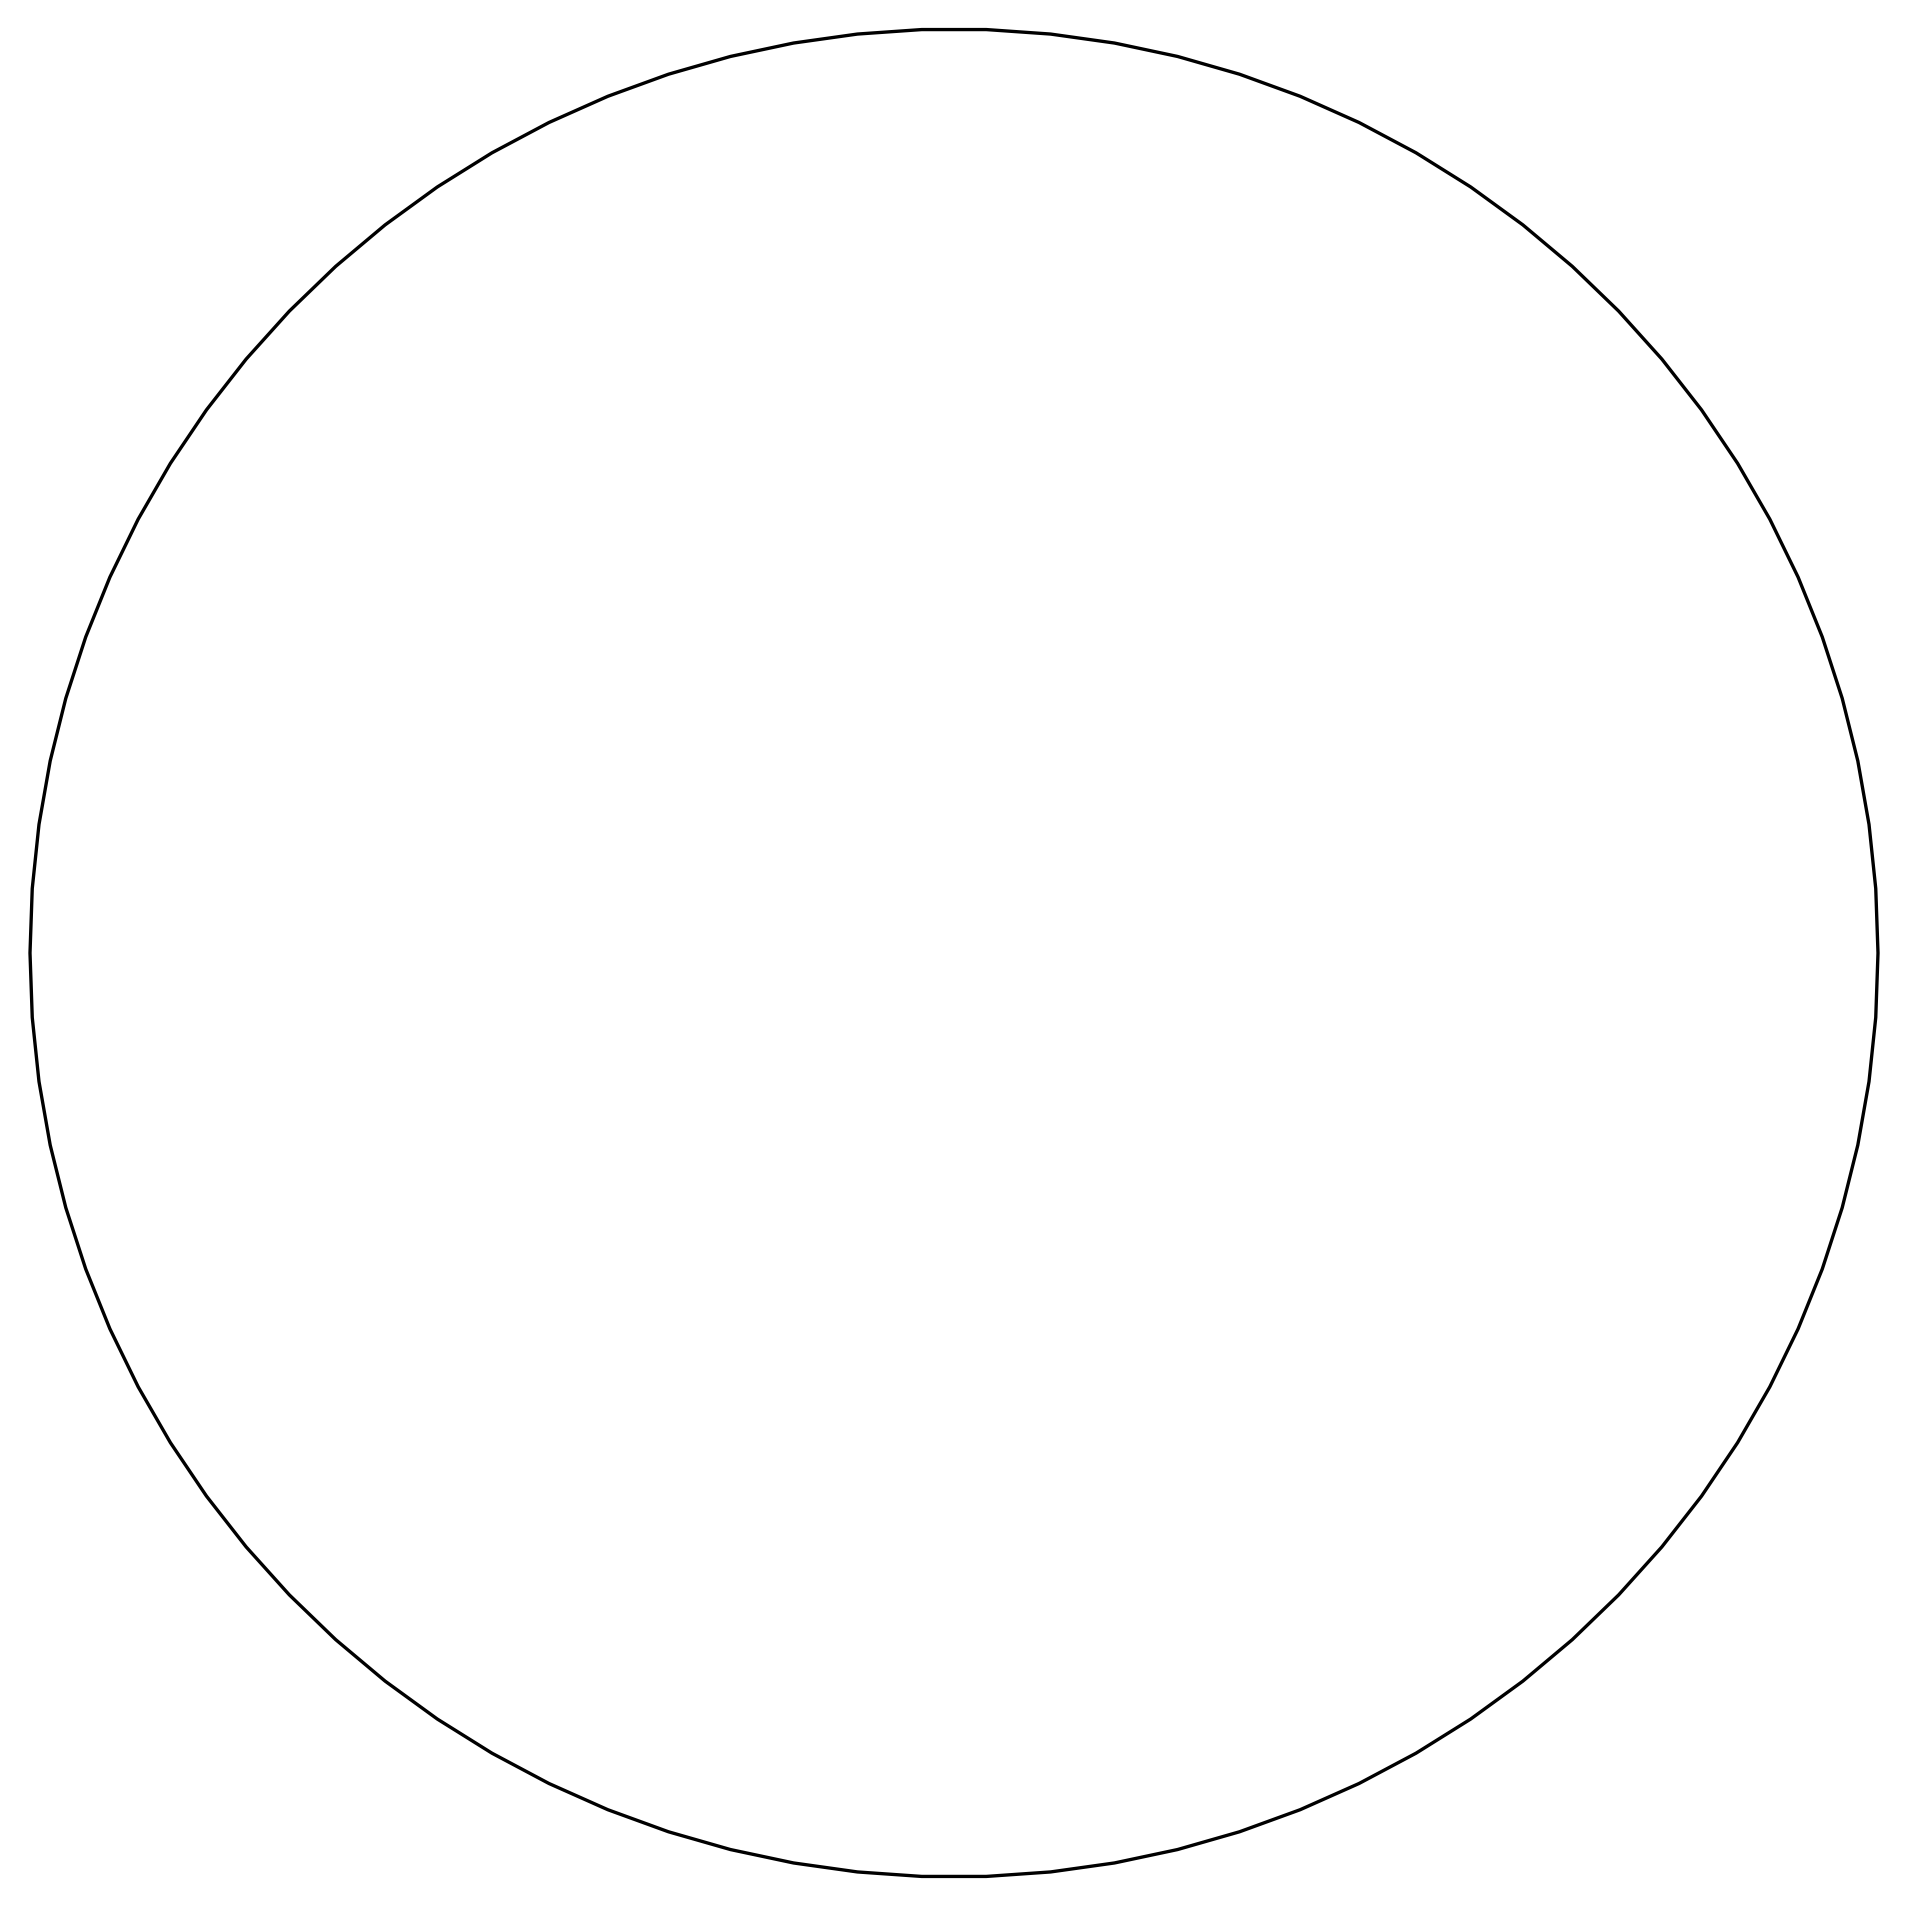

In [ ]:
# Plot of all SOCAT data

map_proj = ccrs.SouthPolarStereo()

fig  = plt.figure(figsize=[8,8], dpi=300) # inches
ax1  = plt.subplot(projection = map_proj)

# Set up plot axes
map_southern_ocean_axes_setup(ax1, fig, 
                              add_gridlines         = False, 
                              color_land            = True,
                              land_facecolor        = land_facecolor,
                              land_edgecolor        = land_edgecolor,
                              fontsize              = fontsize_small,
                              map_facecolor         = plot_facecolor, #'#d7dce8',
                              coast_linewidth       = coast_linewidth)


### Add front and sea ice edge
stf_patch  = plt.Polygon(stf,  fill=False, edgecolor=stf_edgecolor_gmm_map,   zorder=15)
saf_patch  = plt.Polygon(saf,  fill=False, edgecolor=saf_edgecolor_gmm_map,   zorder=14)
pf_patch   = plt.Polygon(pf,   fill=False, edgecolor=pf_edgecolor_gmm_map,    zorder=13)
sacc_patch = plt.Polygon(sacc, fill=False, edgecolor=sacc_edgecolor_gmm_map,  zorder=12)
sie_patch  = plt.Polygon(sie,  fill=True,  edgecolor=sie_edgecolor_gmm_map,   zorder=0,  facecolor=sie_facecolor_gmm_map, alpha=0.4)

ax1.add_patch(stf_patch)
ax1.add_patch(saf_patch)
ax1.add_patch(pf_patch)
ax1.add_patch(sacc_patch)
ax1.add_patch(sie_patch)


### Add land on top
ax1.add_feature(cfeature.LAND, zorder=16, linewidth = coast_linewidth, edgecolor = land_edgecolor, facecolor = land_facecolor)


for k in expokeys:
    dat = expo_dict_3h[k]
    if len(dat) > 0:
        ax1.scatter(x=dat.longitude.values, y=dat.latitude.values, c='m', transform=ccrs.PlateCarree(), zorder=10,  s=1, alpha=0.3)

# plot_circle_boundary(ax1)  # this doesn't work to plot the circle again over top


plt.show()

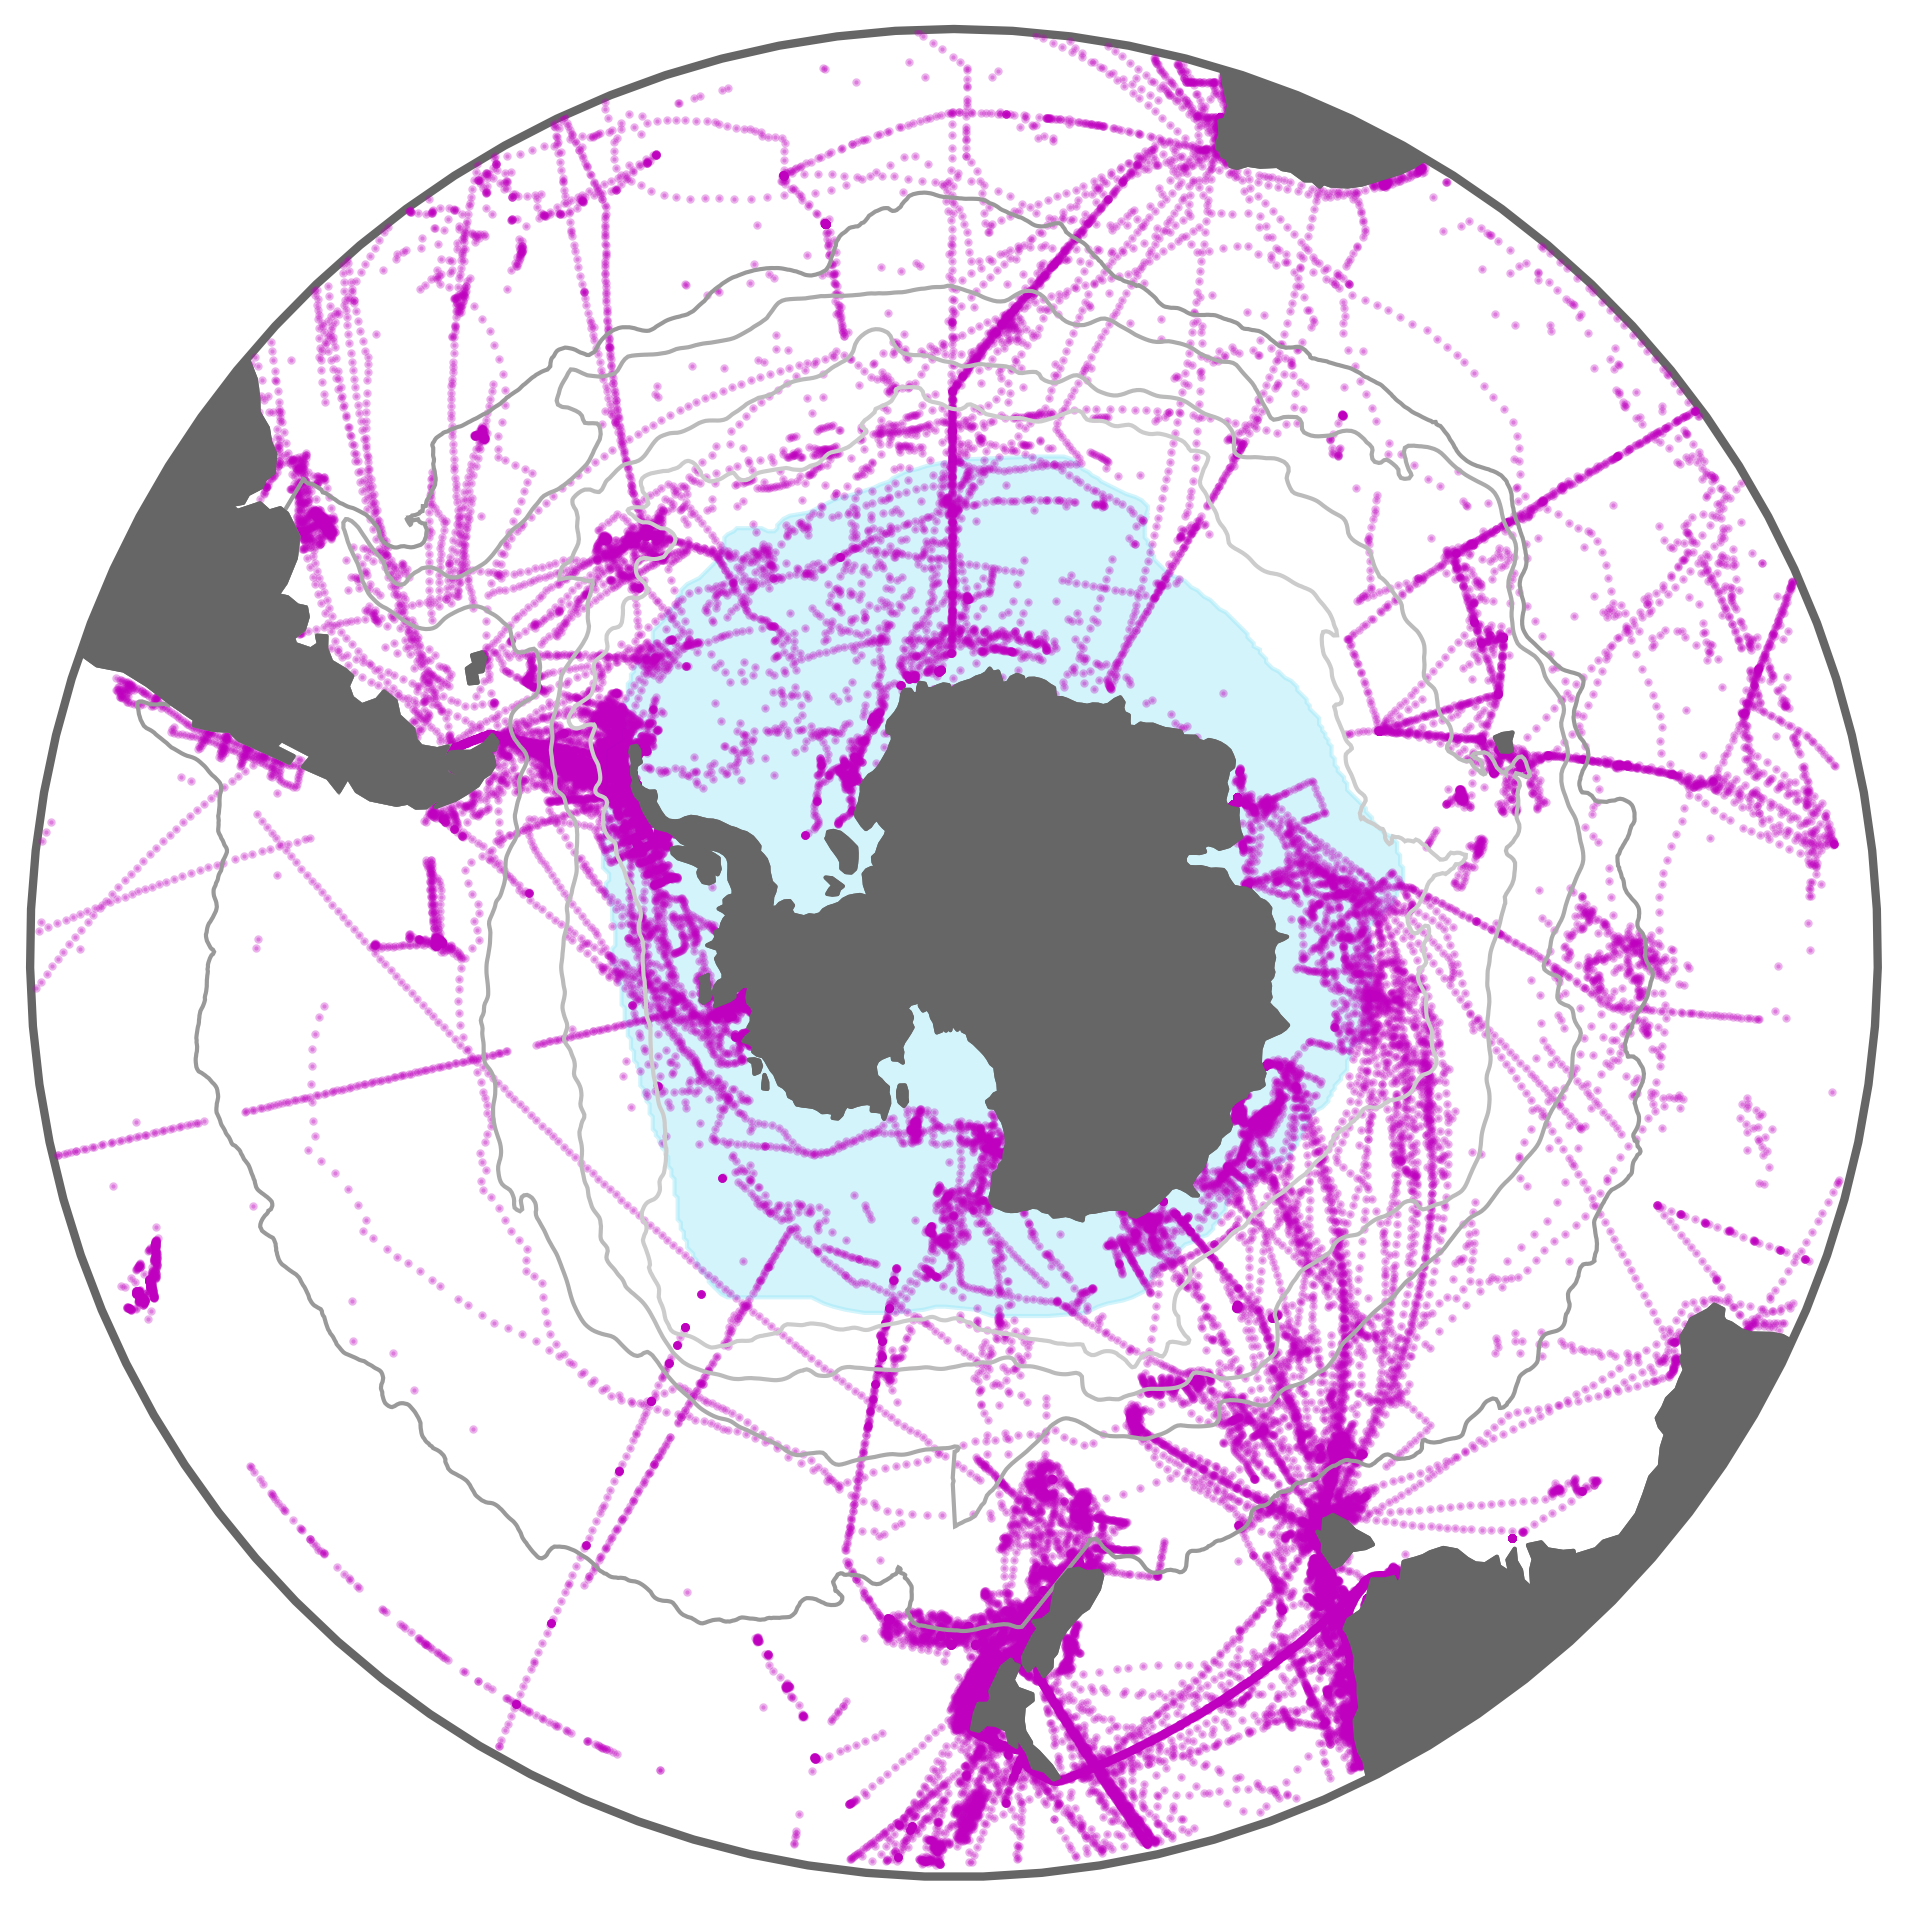

In [ ]:
# Plot of all SOCAT data

map_proj = ccrs.SouthPolarStereo()

fig  = plt.figure(figsize=[8,8], dpi=300) # inches
ax1  = plt.subplot(projection = map_proj)

# Set up plot axes
map_southern_ocean_axes_setup(ax1, fig, 
                              add_gridlines         = False, 
                              color_land            = True,
                              land_facecolor        = land_facecolor,
                              land_edgecolor        = land_edgecolor,
                              fontsize              = fontsize_small,
                              map_facecolor         = plot_facecolor, #'#d7dce8',
                              coast_linewidth       = coast_linewidth)


### Add front and sea ice edge
stf_patch  = plt.Polygon(stf,  fill=False, edgecolor=stf_edgecolor_gmm_map,   zorder=15)
saf_patch  = plt.Polygon(saf,  fill=False, edgecolor=saf_edgecolor_gmm_map,   zorder=14)
pf_patch   = plt.Polygon(pf,   fill=False, edgecolor=pf_edgecolor_gmm_map,    zorder=13)
sacc_patch = plt.Polygon(sacc, fill=False, edgecolor=sacc_edgecolor_gmm_map,  zorder=12)
sie_patch  = plt.Polygon(sie,  fill=True,  edgecolor=sie_edgecolor_gmm_map,   zorder=0,  facecolor=sie_facecolor_gmm_map, alpha=0.4)

ax1.add_patch(stf_patch)
ax1.add_patch(saf_patch)
ax1.add_patch(pf_patch)
ax1.add_patch(sacc_patch)
ax1.add_patch(sie_patch)


### Add land on top
ax1.add_feature(cfeature.LAND, zorder=16, linewidth = coast_linewidth, edgecolor = land_edgecolor, facecolor = land_facecolor)


for k in expokeys:
    dat = expo_dict_3h[k]
    if len(dat) > 0:
        ax1.scatter(x=dat.longitude.values, y=dat.latitude.values, c='m', transform=ccrs.PlateCarree(), zorder=10,  s=1, alpha=0.3)

# plot_circle_boundary(ax1)  # this doesn't work to plot the circle again over top


plt.show()